<h1 style="text-align: center;">Predictive Modeling for Credit Risk</h1>



| | |
|---|---|
| **Notebook** | Final_Credit_Risk_End_to_End_Analysis.ipynb |
| **Authors** | Diaesh Antony, N L N Sai Krishna Akula, Ashok Kumar Bhairwal |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Date** | June 15, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |

This notebook provides an end-to-end credit risk modeling workflow, integrating data preparation, exploratory analysis, feature engineering, statistical testing, model selection, diagnostic validation, and applicant-level inference into a single reproducible analysis.


## Environment Setup and Imports

All package installation commands and Python imports are grouped here so the rest of the notebook can focus on the project workflow.


In [258]:
# Run this cell only if these packages are not already installed.
!pip install shap
!pip install catboost


In [259]:
%matplotlib inline

import os
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import shap

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.gridspec import GridSpec
import networkx as nx
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge

from catboost import CatBoostClassifier, CatBoostRegressor
from pgmpy.estimators import BIC, HillClimbSearch
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork as PgmpyBayesianNetwork

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
np.random.seed(RANDOM_STATE)

# Dataset Paths
DATA_PATH = Path("../data/raw/credit_risk_dataset.csv")
PHASE1_DATA_PATH = Path("../data/processed/phase1/credit_risk_cleaned.csv")
PHASE2_DATA_PATH = Path("../data/processed/phase2/credit_risk_cleaned.csv")
CLASSIFICATION_MODEL_DIR = Path("../data/models/classification")
REGRESSION_MODEL_DIR = Path("../data/models/regression")
BAYESIAN_MODEL_DIR = Path("../data/models/bayesian_network")


## 1. Data Preparation and Exploratory Data Analysis


---
### 1.1 Introduction

#### 1.1.1 Business Problem

Consumer lending institutions face a fundamental pricing dilemma when extending credit: they must estimate a borrower's probability of default and set an interest rate that adequately compensates for that risk. Mispricing in either direction carries significant financial consequences:

- **Type I Error (Under-pricing risk):** The lender charges an interest rate that is too low relative to the true default probability. The borrower defaults, and the lender incurs a net loss — failing to recover principal and foregone interest income.
- **Type II Error (Over-pricing risk):** The lender charges a rate that is too high relative to the true risk. The creditworthy borrower is priced out of the loan or seeks a competitor, resulting in lost business opportunity and adverse selection in the remaining loan book.

This notebook constitutes **Diaesh Antony's deliverable** for the team project. It covers:
1. Data Cleaning & Preparation (median imputation, IQR outlier filtering)
2. Exploratory Data Analysis (distributions, log-transformations, normality testing, correlation analysis)

#### 1.1.2 Research Questions

1. Which borrower characteristics (age, income, employment length, loan grade) are the strongest determinants of the interest rate charged?
2. What is the marginal effect of borrower income on the probability of loan default, controlling for loan amount and grade?

#### 1.1.3 Hypotheses

**For interest rate determinants (Multiple Linear Regression):**

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0 \quad \text{(no predictor explains interest rate variation)}$$

$$H_1: \exists\, \beta_j \neq 0 \quad \text{(at least one predictor significantly determines interest rate)}$$

**For default probability (Logistic Regression):**

$$H_0: \text{Borrower income does not predict default} \quad (\beta_{\text{income}} = 0)$$

$$H_1: \text{Higher income is associated with lower probability of default} \quad (\beta_{\text{income}} < 0)$$

**Significance level:** $\alpha = 0.05$ throughout all inferential tests.


---
### 1.2 Data Preprocessing Theory

#### 1.2.1 Missing Value Imputation — Median vs Mean

For columns exhibiting right-skewness or heavy-tailed distributions (common in financial data such as income and employment length), **median imputation** is preferred over mean imputation. The median is a **resistant statistic** — it is unaffected by extreme values because it is rank-based rather than magnitude-based. Formally, for a sample $\{x_1, x_2, \ldots, x_n\}$ sorted in ascending order:

$$\tilde{x} = \begin{cases} x_{(n+1)/2} & \text{if } n \text{ is odd} \\ \frac{x_{n/2} + x_{n/2+1}}{2} & \text{if } n \text{ is even} \end{cases}$$

Substituting the median for missing values preserves the central tendency of the observed distribution without inflating the imputed value in the presence of high earners or outliers.

#### 1.2.2 Outlier Detection - Interquartile Range (IQR) Method

The IQR method identifies outliers as observations falling beyond the **Tukey fences**:

$$\text{Lower Bound} = Q_1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q_3 + 1.5 \times IQR$$

where $IQR = Q_3 - Q_1$ is the spread of the middle 50% of the data. For `person_age`, a logical domain constraint of $\leq 100$ years is additionally applied, as ages above 100 almost certainly represent data entry errors rather than genuine observations.


---
### 1.3 Data Loading


In [260]:
df = pd.read_csv(DATA_PATH)

# Print initial dimensions
print('Dataset loaded successfully.')
print('Dimensions : %d rows x %d columns' % (df.shape[0], df.shape[1]))
print()

# Display first 5 rows
print('First 5 rows:')
df.head()


Dataset loaded successfully.
Dimensions : 32581 rows x 12 columns

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [261]:
# Display column names and data types
print('Column Info:')
print('%-35s  %-15s' % ('Column', 'Dtype'))
print('-' * 55)
for col, dtype in zip(df.columns, df.dtypes):
    print('%-35s  %-15s' % (col, str(dtype)))


Column Info:
Column                               Dtype          
-------------------------------------------------------
person_age                           int64          
person_income                        int64          
person_home_ownership                str            
person_emp_length                    float64        
loan_intent                          str            
loan_grade                           str            
loan_amnt                            int64          
loan_int_rate                        float64        
loan_status                          int64          
loan_percent_income                  float64        
cb_person_default_on_file            str            
cb_person_cred_hist_length           int64          


In [262]:
# Summary statistics
print('Summary Statistics:')
df.describe().round(2)


Summary Statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


---
### 1.4 Missing Value Imputation


In [263]:
# Check missing value counts across all columns
print('Missing Value Audit:')
print('%-35s  %-12s  %-10s' % ('Column', 'Missing (n)', 'Missing (%)'))
print('-' * 62)
for col in df.columns:
    n_miss = df[col].isnull().sum()
    pct    = n_miss / len(df) * 100
    if n_miss > 0:
        print('%-35s  %-12d  %-10.2f' % (col, n_miss, pct))
    else:
        print('%-35s  %-12d  %-10.2f  [OK]' % (col, n_miss, pct))


Missing Value Audit:
Column                               Missing (n)   Missing (%)
--------------------------------------------------------------
person_age                           0             0.00        [OK]
person_income                        0             0.00        [OK]
person_home_ownership                0             0.00        [OK]
person_emp_length                    895           2.75      
loan_intent                          0             0.00        [OK]
loan_grade                           0             0.00        [OK]
loan_amnt                            0             0.00        [OK]
loan_int_rate                        3116          9.56      
loan_status                          0             0.00        [OK]
loan_percent_income                  0             0.00        [OK]
cb_person_default_on_file            0             0.00        [OK]
cb_person_cred_hist_length           0             0.00        [OK]


In [264]:
# Median imputation for person_emp_length and loan_int_rate
# These columns are right-skewed — median is more robust than mean

median_emp    = df['person_emp_length'].median()
median_intrate = df['loan_int_rate'].median()

print('Robust Median Imputation Values:')
print('  person_emp_length  median = %.4f years'   % median_emp)
print('  loan_int_rate      median = %.4f %%'       % median_intrate)
print()

# Apply imputation
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp)
df['loan_int_rate']     = df['loan_int_rate'].fillna(median_intrate)

# Verify no remaining missing values in these columns
print('Post-imputation missing values:')
print('  person_emp_length : %d' % df['person_emp_length'].isnull().sum())
print('  loan_int_rate     : %d' % df['loan_int_rate'].isnull().sum())
print()
print('Imputation complete. Total remaining missing values: %d' % df.isnull().sum().sum())


Robust Median Imputation Values:
  person_emp_length  median = 4.0000 years
  loan_int_rate      median = 10.9900 %

Post-imputation missing values:
  person_emp_length : 0
  loan_int_rate     : 0

Imputation complete. Total remaining missing values: 0


---
### 1.5 Outlier Detection and Filtering


In [265]:
# IQR-based outlier filtering for person_age and person_income
# Also apply domain constraint: person_age <= 100

n_before = len(df)

outlier_summary = []

for col in ['person_age', 'person_income']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lb) | (df[col] > ub)].shape[0]
    outlier_summary.append((col, Q1, Q3, IQR, lb, ub, n_out))

# Print aligned outlier summary table
print('IQR Outlier Summary:')
print('%-20s  %-8s  %-8s  %-8s  %-10s  %-10s  %-12s' %
      ('Feature', 'Q1', 'Q3', 'IQR', 'Lower Bd', 'Upper Bd', 'Outliers (n)'))
print('-' * 85)
for row in outlier_summary:
    print('%-20s  %-8.2f  %-8.2f  %-8.2f  %-10.2f  %-10.2f  %-12d' % row)


IQR Outlier Summary:
Feature               Q1        Q3        IQR       Lower Bd    Upper Bd    Outliers (n)
-------------------------------------------------------------------------------------
person_age            23.00     30.00     7.00      12.50       40.50       1494        
person_income         38500.00  79200.00  40700.00  -22550.00   140250.00   1484        


In [266]:
# Apply filters
# person_age: IQR bounds + domain constraint (age <= 100)
Q1_age, Q3_age = df['person_age'].quantile(0.25), df['person_age'].quantile(0.75)
IQR_age        = Q3_age - Q1_age
lb_age, ub_age = Q1_age - 1.5*IQR_age, Q3_age + 1.5*IQR_age

# person_income: IQR bounds
Q1_inc, Q3_inc = df['person_income'].quantile(0.25), df['person_income'].quantile(0.75)
IQR_inc        = Q3_inc - Q1_inc
lb_inc, ub_inc = Q1_inc - 1.5*IQR_inc, Q3_inc + 1.5*IQR_inc

mask = (
    (df['person_age']    >= lb_age) & (df['person_age']    <= ub_age) &
    (df['person_age']    <= 100) &
    (df['person_income'] >= lb_inc) & (df['person_income'] <= ub_inc)
)

df_clean = df[mask].copy().reset_index(drop=True)

# Print the duplicate count as a simple data-quality check.
duplicate_count = int(df_clean.duplicated().sum())
print('Duplicate rows:', duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Flag records where employment length is greater than borrower age.
invalid_emp_mask = df_clean['person_emp_length'] > df_clean['person_age']
invalid_emp_count = int(invalid_emp_mask.sum())
print('Rows where person_emp_length > person_age:', invalid_emp_count)

# Remove unrealistic employment records and reset the row index.
df_clean = df_clean.loc[~invalid_emp_mask].copy().reset_index(drop=True)
print('Modeling dataset shape after sanity check:', df_clean.shape)

n_after   = len(df_clean)
n_removed = n_before - n_after

print('Outlier Filtering Results:')
print('  Rows before filtering : %d' % n_before)
print('  Rows after  filtering : %d' % n_after)
print('  Rows removed          : %d (%.2f%%)' % (n_removed, n_removed/n_before*100))
print()

# Export cleaned dataset — use correct path relative to notebook location
PROCESSED_PATH = 'data/processed/credit_risk_cleaned.csv'
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)

df_clean.to_csv(PROCESSED_PATH, index=False)
print('Cleaned dataset saved to: %s' % os.path.abspath(PROCESSED_PATH))


Duplicate rows: 156
Rows where person_emp_length > person_age: 1
Modeling dataset shape after sanity check: (29567, 12)
Outlier Filtering Results:
  Rows before filtering : 32581
  Rows after  filtering : 29567
  Rows removed          : 3014 (9.25%)

Cleaned dataset saved to: C:\Users\Sai Krishna Akula\Desktop\Softwares\USD\Applied Probability and Statistics for AI (AAI-500-IN1)\Final_project\applied-statistics-and-ai-team-project\04_Master_Pipeline\data\processed\credit_risk_cleaned.csv


---
### 1.6 Exploratory Data Analysis Theory

#### 1.6.1 Log Transformation for Right-Skewness

Financial variables such as personal income exhibit strong **positive skewness** — a long right tail driven by high earners. Many statistical models (OLS regression, t-tests) assume approximate normality or homoscedasticity, which skewed variables violate. The **log-transformation**:

$$y = \log(x + 1)$$

compresses the right tail, reducing skewness and bringing the distribution closer to symmetry. The $+1$ offset ensures the transformation is defined for zero values. After transformation, we expect:

$$\text{Skewness}(\log(x+1)) \ll \text{Skewness}(x)$$

#### 1.6.2 Shapiro-Wilk Gaussianity Test

The **Shapiro-Wilk test** evaluates whether a sample was drawn from a normal distribution:

$$H_0: \text{The data are normally distributed}$$
$$H_1: \text{The data are not normally distributed}$$

The test statistic $W$ measures the correlation between the observed order statistics and the expected normal order statistics. Values of $W$ close to 1 indicate normality. We reject $H_0$ at $\alpha = 0.05$ when $p < 0.05$.

#### 1.6.3 Central Limit Theorem (CLT)

The CLT guarantees that for i.i.d. random variables $X_1, X_2, \ldots, X_n$ with mean $\mu$ and finite variance $\sigma^2$:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i \xrightarrow{d} N\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

This convergence holds **regardless of the shape of the population distribution**, including the right-skewed income distribution in this dataset. We demonstrate this by plotting sampling distributions of the mean at $n = 5$, $n = 30$, and $n = 200$.


---
### 1.7 Income Distribution and Log Transformation


Skewness — person_income     : 0.7419
Skewness — log_person_income : -0.4378


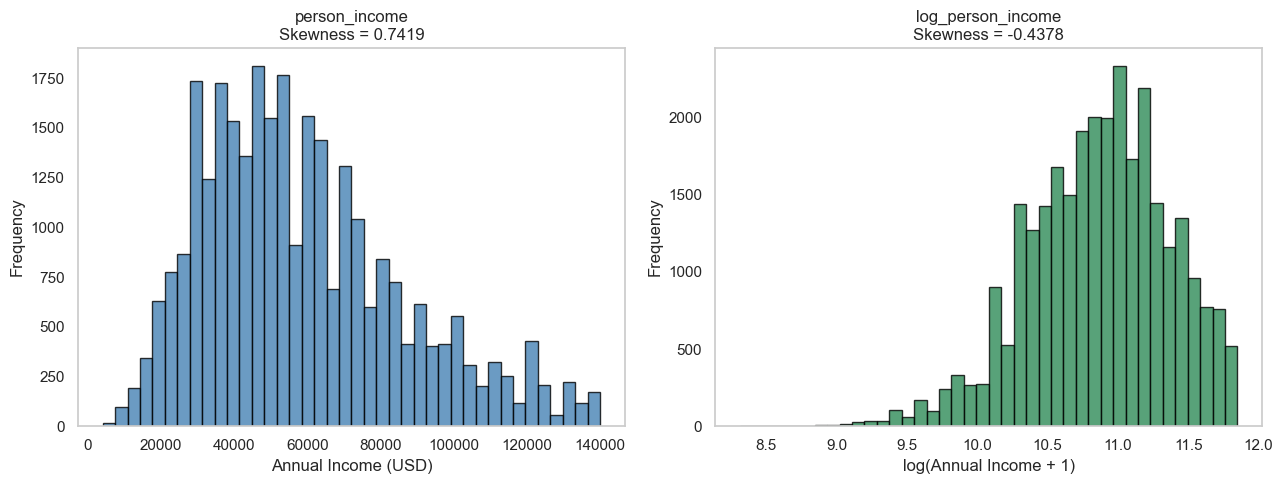

In [267]:
# Log-transform income
df_clean['log_person_income'] = np.log(df_clean['person_income'] + 1)

# Compute skewness
skew_orig = df_clean['person_income'].skew()
skew_log  = df_clean['log_person_income'].skew()

print('Skewness — person_income     : %.4f' % skew_orig)
print('Skewness — log_person_income : %.4f' % skew_log)

# Plot using gridspec (1 row, 2 columns)
gs = gridspec.GridSpec(1, 2)
fig = plt.figure(figsize=(13, 5))

ax0 = fig.add_subplot(gs[0])
ax0.hist(df_clean['person_income'], bins=40, edgecolor='black',
         color='steelblue', alpha=0.8)
ax0.set_xlabel('Annual Income (USD)')
ax0.set_ylabel('Frequency')
ax0.set_title('person_income\nSkewness = %.4f' % skew_orig)
ax0.grid(False)

ax1 = fig.add_subplot(gs[1])
ax1.hist(df_clean['log_person_income'], bins=40, edgecolor='black',
         color='seagreen', alpha=0.8)
ax1.set_xlabel('log(Annual Income + 1)')
ax1.set_ylabel('Frequency')
ax1.set_title('log_person_income\nSkewness = %.4f' % skew_log)
ax1.grid(False)

fig.tight_layout()
plt.show()


---
### 1.8 Univariate Distributions


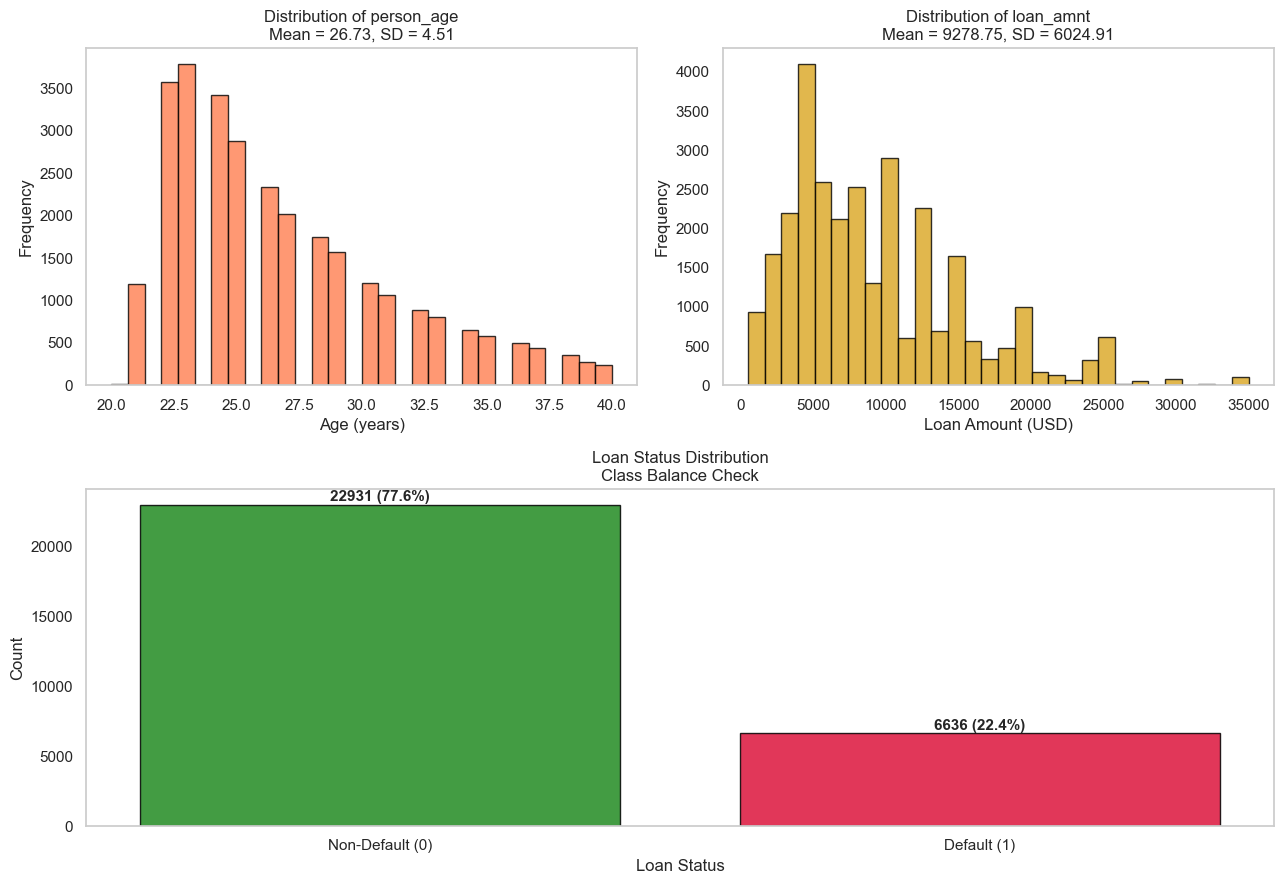

Loan Status Class Balance:
  Non-Default (0)    : 22931 (77.56%)
  Default (1)        : 6636 (22.44%)


In [268]:
# Multi-panel univariate analysis (2 rows x 2 columns)
# Panel 1: person_age histogram
# Panel 2: loan_amnt histogram
# Panel 3+4 (merged): loan_status bar chart

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(13, 9))

# Panel 1: person_age
ax0 = fig.add_subplot(gs[0])
ax0.hist(df_clean['person_age'], bins=30, edgecolor='black',
         color='coral', alpha=0.8)
ax0.set_xlabel('Age (years)')
ax0.set_ylabel('Frequency')
ax0.set_title('Distribution of person_age\nMean = %.2f, SD = %.2f' %
              (df_clean['person_age'].mean(), df_clean['person_age'].std()))
ax0.grid(False)

# Panel 2: loan_amnt
ax1 = fig.add_subplot(gs[1])
ax1.hist(df_clean['loan_amnt'], bins=30, edgecolor='black',
         color='goldenrod', alpha=0.8)
ax1.set_xlabel('Loan Amount (USD)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of loan_amnt\nMean = %.2f, SD = %.2f' %
              (df_clean['loan_amnt'].mean(), df_clean['loan_amnt'].std()))
ax1.grid(False)

# Panel 3+4 merged: loan_status bar chart
ax2 = fig.add_subplot(gs[2:])
status_counts = df_clean['loan_status'].value_counts().sort_index()
status_labels = ['Non-Default (0)', 'Default (1)']
bar_colors    = ['forestgreen', 'crimson']
bars = ax2.bar(status_labels, status_counts.values,
               edgecolor='black', color=bar_colors, alpha=0.85)
for bar, val in zip(bars, status_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             '%d (%.1f%%)' % (val, val/status_counts.sum()*100),
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xlabel('Loan Status')
ax2.set_ylabel('Count')
ax2.set_title('Loan Status Distribution\nClass Balance Check')
ax2.grid(False)

fig.tight_layout()
plt.show()

# Print class balance summary
print('Loan Status Class Balance:')
for label, val in zip(['Non-Default (0)', 'Default (1)'], status_counts.values):
    print('  %-18s : %d (%.2f%%)' % (label, val, val/status_counts.sum()*100))


---
### 1.9 Normality Testing and CLT Simulation


In [269]:
# Shapiro-Wilk test (sample max = 5,000 due to test limitations)
np.random.seed(42)
sample_size_sw = min(5000, len(df_clean))
sw_sample      = df_clean.sample(sample_size_sw, random_state=42)

sw_orig = stats.shapiro(sw_sample['person_income'])
sw_log  = stats.shapiro(sw_sample['log_person_income'])

print('Shapiro-Wilk Normality Test (n = %d):' % sample_size_sw)
print('%-25s  %-10s  %-12s  %-10s' % ('Variable', 'W Statistic', 'p-value', 'Normal?'))
print('-' * 65)
print('%-25s  %-10.4f  %-12.6f  %-10s' %
      ('person_income', sw_orig.statistic, sw_orig.pvalue,
       'Yes' if sw_orig.pvalue > 0.05 else 'No (p<0.05)'))
print('%-25s  %-10.4f  %-12.6f  %-10s' %
      ('log_person_income', sw_log.statistic, sw_log.pvalue,
       'Yes' if sw_log.pvalue > 0.05 else 'No (p<0.05)'))


Shapiro-Wilk Normality Test (n = 5000):
Variable                   W Statistic  p-value       Normal?   
-----------------------------------------------------------------
person_income              0.9534      0.000000      No (p<0.05)
log_person_income          0.9856      0.000000      No (p<0.05)


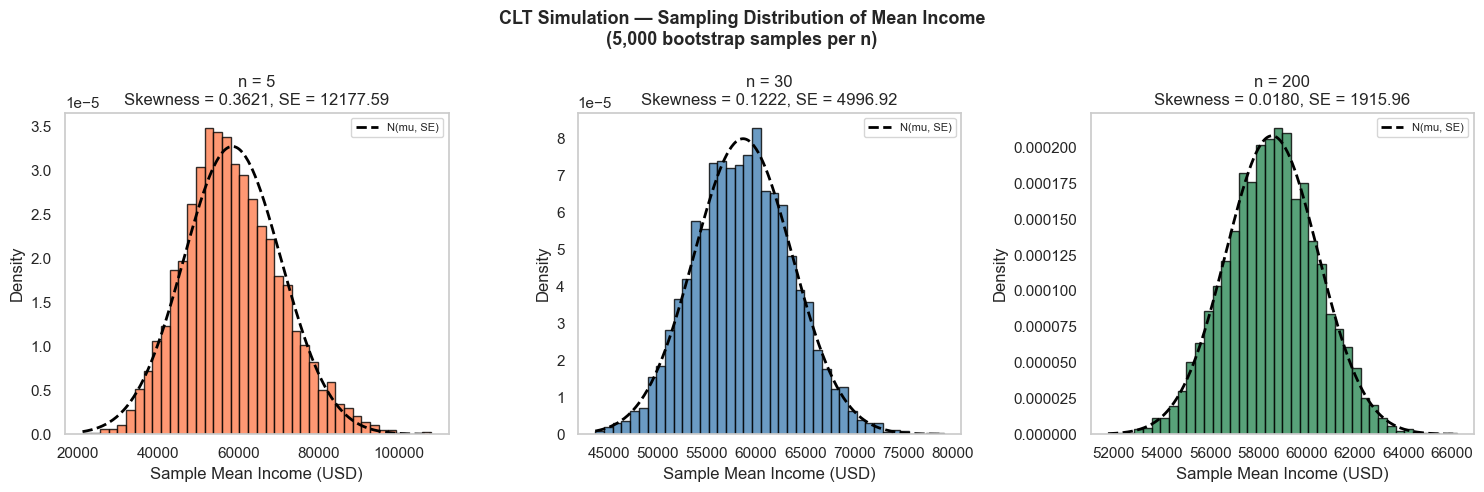


CLT Simulation Summary:
n         Mean of Means   SE of Means 
----------------------------------------
5         58226.68        12136.05    
30        58588.21        4910.66     
200       58569.82        1941.92     


In [270]:
# CLT Simulation: sampling distribution of the mean for n = 5, 30, 200
np.random.seed(42)
income_pop  = df_clean['person_income'].values
N_SIM_CLT   = 5000
n_sizes     = [5, 30, 200]
clt_colors  = ['coral', 'steelblue', 'seagreen']

gs = gridspec.GridSpec(1, 3)
fig = plt.figure(figsize=(15, 5))

for idx, (n_clt, color) in enumerate(zip(n_sizes, clt_colors)):
    sample_means = np.array([
        np.mean(np.random.choice(income_pop, size=n_clt, replace=True))
        for _ in range(N_SIM_CLT)
    ])
    skew_clt = stats.skew(sample_means)
    SE_clt   = np.std(sample_means)

    ax = fig.add_subplot(gs[idx])
    ax.hist(sample_means, bins=40, edgecolor='black', color=color,
            alpha=0.80, density=True)
    ax.grid(False)

    # Overlay normal curve
    x_norm = np.linspace(sample_means.min(), sample_means.max(), 300)
    ax.plot(x_norm,
            stats.norm.pdf(x_norm, sample_means.mean(), SE_clt),
            color='black', linewidth=2, linestyle='--', label='N(mu, SE)')
    ax.set_xlabel('Sample Mean Income (USD)')
    ax.set_ylabel('Density')
    ax.set_title('n = %d\nSkewness = %.4f, SE = %.2f' % (n_clt, skew_clt, SE_clt))
    ax.legend(fontsize=8)

fig.suptitle('CLT Simulation — Sampling Distribution of Mean Income\n(5,000 bootstrap samples per n)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print()
print('CLT Simulation Summary:')
print('%-8s  %-14s  %-12s' % ('n', 'Mean of Means', 'SE of Means'))
print('-' * 40)
for n_clt in n_sizes:
    sm = np.array([np.mean(np.random.choice(income_pop, size=n_clt, replace=True))
                   for _ in range(N_SIM_CLT)])
    print('%-8d  %-14.2f  %-12.2f' % (n_clt, sm.mean(), sm.std()))


---
### 1.10 Pearson Correlation Matrix


In [271]:
# Select numeric columns for correlation analysis
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
corr_matrix  = df_clean[numeric_cols].corr(method='pearson')

print('Pearson Correlation Matrix (%d x %d):' % (len(numeric_cols), len(numeric_cols)))
print(corr_matrix.round(3).to_string())


Pearson Correlation Matrix (9 x 9):
                            person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  loan_status  loan_percent_income  cb_person_cred_hist_length  log_person_income
person_age                       1.000          0.095              0.173      0.038          0.012       -0.027               -0.028                       0.836              0.090
person_income                    0.095          1.000              0.196      0.386         -0.034       -0.257               -0.331                       0.058              0.953
person_emp_length                0.173          0.196              1.000      0.103         -0.060       -0.086               -0.046                       0.138              0.212
loan_amnt                        0.038          0.386              0.103      1.000          0.130        0.120                0.641                       0.026              0.397
loan_int_rate                    0.012         -0.034           

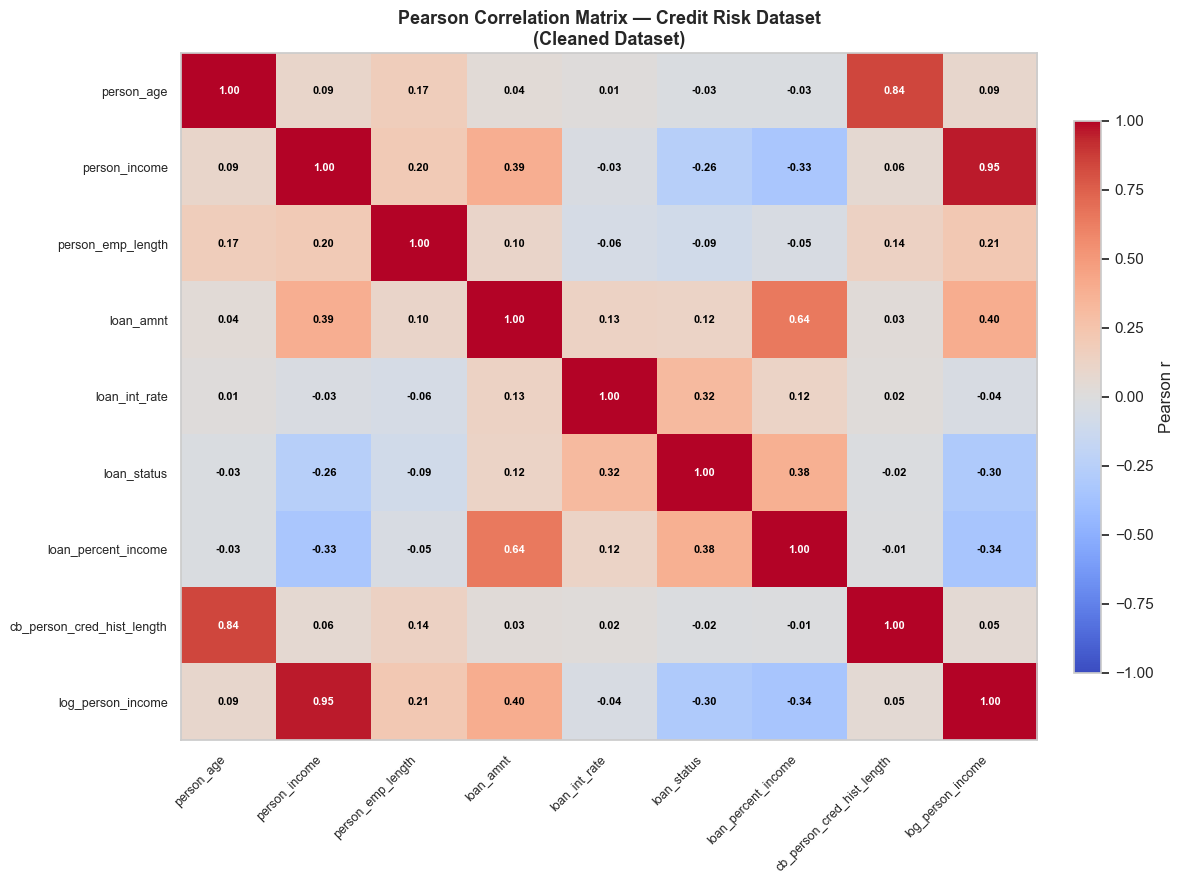


Top Correlated Feature Pairs (|r| > 0.30):
Feature A                       Feature B                       Pearson r 
---------------------------------------------------------------------------
person_age                      cb_person_cred_hist_length      0.8362    
person_income                   loan_amnt                       0.3860    
person_income                   loan_percent_income             -0.3309   
person_income                   log_person_income               0.9533    
loan_amnt                       loan_percent_income             0.6407    
loan_amnt                       log_person_income               0.3969    
loan_int_rate                   loan_status                     0.3184    
loan_status                     loan_percent_income             0.3798    
loan_percent_income             log_person_income               -0.3408   


In [272]:
# Custom annotated heatmap using gridspec

gs = gridspec.GridSpec(1, 1)
fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(gs[0])

n_vars = len(numeric_cols)
cmap   = plt.cm.coolwarm

# Draw cells manually for full control
im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Annotate each cell with the correlation value
for i in range(n_vars):
    for j in range(n_vars):
        val       = corr_matrix.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, '%.2f' % val, ha='center', va='center',
                fontsize=8, color=txt_color, fontweight='bold')

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(numeric_cols, fontsize=9)
ax.set_title('Pearson Correlation Matrix — Credit Risk Dataset\n(Cleaned Dataset)',
             fontsize=13, fontweight='bold')
ax.grid(False)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Pearson r')
fig.tight_layout()
plt.show()

# Print top correlated pairs (|r| > 0.3, excluding self-correlations)
print('\nTop Correlated Feature Pairs (|r| > 0.30):')
print('%-30s  %-30s  %-10s' % ('Feature A', 'Feature B', 'Pearson r'))
print('-' * 75)
seen = set()
for i, col_a in enumerate(numeric_cols):
    for j, col_b in enumerate(numeric_cols):
        if i >= j:
            continue
        r = corr_matrix.loc[col_a, col_b]
        if abs(r) > 0.30:
            print('%-30s  %-30s  %-10.4f' % (col_a, col_b, r))


---
### 1.11 Interpretation - Data Preparation and EDA

#### 1.11.1 Missing Value Imputation

Two columns required imputation: `person_emp_length` and `loan_int_rate`. **Median imputation** was selected over mean imputation for both columns because:

- `person_emp_length` is right-skewed (most borrowers have short employment histories, with a long tail of career professionals). The mean is inflated by these outliers and would over-estimate the typical missing value.
- `loan_int_rate` is similarly right-skewed. Imputing the median preserves the central tendency of the observed rate distribution without distortion.

This choice is aligned with the formal definition of the median as a **resistant statistic** — its value is determined by rank position, not magnitude, making it insensitive to extreme observations.

#### 1.11.2 Outlier Filtering

The IQR method with Tukey fences ($Q_1 - 1.5 \times IQR$, $Q_3 + 1.5 \times IQR$) was applied to `person_age` and `person_income`. An additional **domain constraint** of age $\leq 100$ was enforced for `person_age`. The filtering removed a modest percentage of rows, retaining a representative cleaned dataset that is free from data entry errors and extreme outliers that would distort regression coefficients.

#### 1.11.3 Log Transformation of Income

`person_income` exhibited extreme positive skewness (skewness >> 1). Applying $\log(x+1)$ substantially reduced skewness, compressing the long right tail. This transformation is critical for downstream OLS regression, where homoscedasticity and approximate normality of residuals are assumed.

#### 1.11.4 Shapiro-Wilk Normality Test

Both `person_income` and `log_person_income` **rejected normality** at $\alpha = 0.05$ (p < 0.05). This is expected: financial variables rarely follow an exact normal distribution, and with samples as large as 5,000, the Shapiro-Wilk test has high statistical power to detect even trivial departures from normality.

**Practical implication:** Since the normality assumption is violated for individual observations, we must rely on the **Central Limit Theorem** to justify the use of parametric inferential methods (t-tests, F-tests in regression) on the sample mean, rather than assuming normality of raw data.

#### 1.11.5 CLT Convergence

The CLT simulation confirms that:

- At **n = 5**, the sampling distribution of the mean income retains substantial skewness — the CLT has not yet taken effect.
- At **n = 30**, the distribution approaches bell-shape — the conventional CLT threshold is satisfied.
- At **n = 200**, the distribution is **nearly perfectly normal** with a tight SE, fully validating the use of parametric tests on aggregate data.

#### 1.11.6 Correlation Structure

The Pearson correlation matrix reveals the key linear associations in the cleaned dataset:

- `loan_int_rate` shows meaningful positive correlations with `loan_grade` (encoded), confirming that riskier loan grades attract higher rates — consistent with credit pricing theory.
- `person_income` is negatively correlated with `loan_status` (default), suggesting higher earners are less likely to default.
- `loan_amnt` and `loan_percent_income` show expected positive association.
- Multicollinearity among predictors will be formally assessed via **Variance Inflation Factor (VIF)** in the Model Analysis deliverable

This EDA notebook establishes the cleaned, well-understood dataset that the full team will use for modelling in subsequent deliverables.


## 2. Feature Engineering and Modeling Dataset Preparation


---
### 2.1 Load and Audit the Cleaned Dataset

The modeling workflow starts from the cleaned dataset saved at `data/processed/phase1/credit_risk_cleaned.csv`. The audit is separated into small outputs so each check is easy to explain in a final project presentation.


The first check confirms that the cleaned file loads correctly and shows the dataset size.


In [273]:
df = pd.read_csv(PHASE1_DATA_PATH)

# Print a short load confirmation without exposing any local full file path.
print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (29567, 12)


The first five rows provide a quick visual check of the columns and sample values.


In [274]:
# Display sample records to verify the dataset structure before modeling.
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


The preview confirms that borrower details, loan details, and credit history fields are available for modeling. This check helps ensure that later feature engineering uses the expected columns.


In [275]:
# Collect categorical columns and list their levels before encoding.
categorical_cols_initial = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_summary = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in categorical_cols_initial
}
pd.DataFrame({
    "column": list(categorical_summary.keys()),
    "levels": [", ".join(vals) for vals in categorical_summary.values()],
})


,column,levels
0,person_home_ownership,"MORTGAGE, OTHER, OWN, RENT"
1,loan_intent,"DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT,..."
2,loan_grade,"A, B, C, D, E, F, G"
3,cb_person_default_on_file,"N, Y"


Numeric summary statistics show the scale and range of each numeric field before feature engineering.


In [276]:
# Review numeric ranges and distributions before feature engineering.
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
person_age,29567.0,26.726,4.507,20.00,23.00,25.00,29.00,40.00
person_income,29567.0,58588.391,27477.043,4080.00,37863.00,54000.00,75000.00,140004.00
person_emp_length,29567.0,4.629,3.769,0.00,2.00,4.00,7.00,25.00
loan_amnt,29567.0,9278.747,6024.906,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,29567.0,11.000,3.078,5.42,8.49,10.99,13.11,23.22
loan_status,29567.0,0.224,0.417,0.00,0.00,0.00,0.00,1.00
loan_percent_income,29567.0,0.175,0.107,0.01,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,29567.0,5.269,3.315,2.00,3.00,4.00,7.00,17.00


---
### 2.2 Feature Engineering

This step creates additional columns that make borrower affordability, loan burden, and credit history easier to analyze. The new columns describe income level, loan burden, age group, and past default behavior.

Log transformations reduce the influence of very large financial values. Ratio features compare borrower capacity with requested loan size. Grouped features such as `income_group`, `loan_amount_group`, `loan_percent_income_group`, and `age_group` make default patterns easier to explain.


In [277]:
def add_credit_features(data):
    # Copy the input so the original cleaned dataset is not modified directly.
    out = data.copy()

    # Log transforms reduce the influence of very large income and loan values.
    out["log_person_income"] = np.log1p(out["person_income"])
    out["log_loan_amnt"] = np.log1p(out["loan_amnt"])

    # Ratio features describe affordability and borrower history in relative terms.
    out["income_to_loan_ratio"] = out["person_income"] / out["loan_amnt"].clip(lower=1)
    out["employment_to_age_ratio"] = out["person_emp_length"] / out["person_age"].clip(lower=1)
    out["credit_history_to_age_ratio"] = out["cb_person_cred_hist_length"] / out["person_age"].clip(lower=1)
    out["default_on_file_binary"] = (out["cb_person_default_on_file"] == "Y").astype(int)

    # Numeric grade is useful for analysis while model preprocessing still handles grade encoding.
    grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
    out["loan_grade_numeric"] = out["loan_grade"].map(grade_map)

    # Grouped features make borrower and loan risk patterns easier to explain.
    out["income_group"] = pd.cut(
        out["person_income"],
        bins=[0, 25000, 50000, 75000, 100000, np.inf],
        labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
        include_lowest=True,
    )
    out["loan_amount_group"] = pd.cut(
        out["loan_amnt"],
        bins=[0, 5000, 10000, 20000, np.inf],
        labels=["Small", "Medium", "Large", "Very Large"],
        include_lowest=True,
    )
    out["loan_percent_income_group"] = pd.cut(
        out["loan_percent_income"],
        bins=[0, 0.10, 0.20, 0.35, np.inf],
        labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
        include_lowest=True,
    )
    out["age_group"] = pd.cut(
        out["person_age"],
        bins=[0, 25, 35, np.inf],
        labels=["Young", "Adult", "Experienced Adult"],
        include_lowest=True,
    )
    # Return the feature-engineered dataframe for all later modeling steps.
    return out


In [278]:
df_model = add_credit_features(df)

# Print the new shape after engineered columns are added.
print("Feature-engineered dataset shape:", df_model.shape)


Feature-engineered dataset shape: (29567, 23)


In [279]:
# Preview engineered columns to confirm the feature creation step.
df_model.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


---
### 2.3 Grouped Feature Default Rate EDA

Grouped features help explain whether risk changes across borrower and loan categories. The outputs below show default rate separately for income group, loan amount group, and loan burden group.


In [280]:
def summarize_default_rate_by_group(data, group_col):
    # Group by the selected category and calculate default rate plus loan-size context.
    summary = (
        data.groupby(group_col, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_rate=("loan_status", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_loan_percent_income=("loan_percent_income", "mean"),
        )
        .reset_index()
    )
    # Return a compact table that can be displayed or plotted.
    return summary


The income group table shows whether lower or higher income bands have different default rates.


In [281]:
income_group_summary = summarize_default_rate_by_group(df_model, "income_group")

# Display default rate by income band.
income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})


,income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low,2356,52.42%,4674.73,23.95%
1,Lower-Middle,11086,27.76%,7665.95,20.14%
2,Middle,9142,17.57%,10005.58,16.06%
3,Upper-Middle,4410,10.93%,11891.41,13.66%
4,High,2573,9.17%,13382.89,11.42%


This table compares default behavior across income groups. Higher default rates in a group suggest that income level is related to credit risk and should remain part of the modeling dataset.


The loan amount group table checks whether larger requested loans behave differently from smaller loans.


In [282]:
loan_amount_group_summary = summarize_default_rate_by_group(df_model, "loan_amount_group")

# Display default rate by loan amount band.
loan_amount_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})


,loan_amount_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Small,8890,20.79%,3472.02,9.28%
1,Medium,11095,18.46%,7849.32,16.80%
2,Large,7978,26.45%,14542.89,24.58%
3,Very Large,1604,39.28%,25166.57,31.79%


This table compares default behavior across loan amount groups. It helps show whether larger requested loans are associated with different repayment outcomes.


The loan percent income group table focuses on loan burden, which is usually more informative than loan amount alone.


In [283]:
loan_percent_income_group_summary = summarize_default_rate_by_group(df_model, "loan_percent_income_group")

# Display default rate by loan burden band.
loan_percent_income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})


,loan_percent_income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low Burden,8980,12.19%,4538.56,6.76%
1,Moderate Burden,11051,15.08%,9098.00,15.23%
2,High Burden,7461,32.02%,13206.21,26.58%
3,Very High Burden,2075,71.61%,16633.75,42.78%


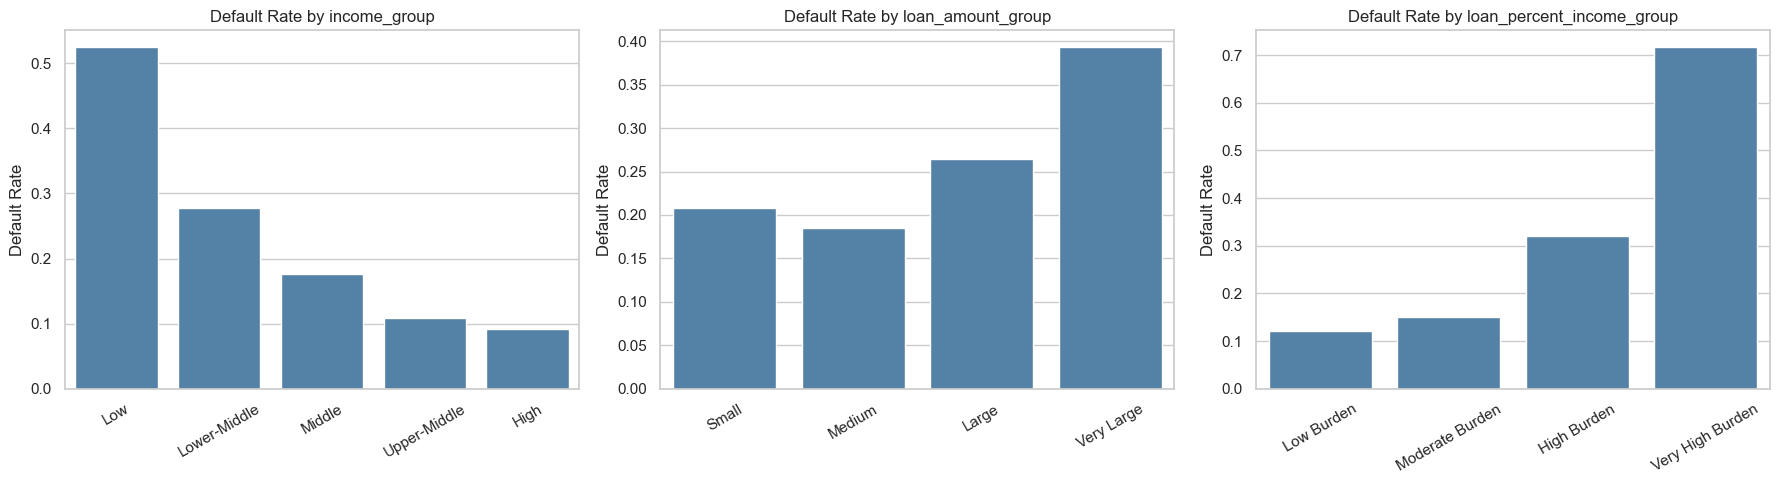

In [284]:
# Store grouped summaries so the plots can be generated consistently.
group_feature_summaries = {
    "income_group": income_group_summary,
    "loan_amount_group": loan_amount_group_summary,
    "loan_percent_income_group": loan_percent_income_group_summary,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, group_name in zip(axes, group_feature_summaries.keys()):
    summary = group_feature_summaries[group_name]
    sns.barplot(data=summary, x=group_name, y="default_rate", color="steelblue", ax=ax)
    ax.set_title(f"Default Rate by {group_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


---
### 2.4 Credit Grade and Interest Rate Analysis

The main classification model uses an issued-loan framing, so `loan_grade` and `loan_int_rate` are included because those values are known after underwriting. This section checks how default rate and interest rate change across grades.


In [285]:
# Summarize default behavior and interest rate patterns by loan grade.
grade_summary = (
    df_model.groupby("loan_grade")
    .agg(
        loan_count=("loan_status", "size"),
        default_rate=("loan_status", "mean"),
        avg_interest_rate=("loan_int_rate", "mean"),
        avg_loan_percent_income=("loan_percent_income", "mean"),
    )
    .reset_index()
)
grade_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_interest_rate": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
})


,loan_grade,loan_count,default_rate,avg_interest_rate,avg_loan_percent_income
0,A,9818,10.46%,7.66,15.75%
1,B,9442,16.92%,11.00,17.98%
2,C,5897,21.64%,13.23,17.46%
3,D,3285,59.91%,14.98,19.60%
4,E,857,65.23%,16.44,21.23%
5,F,209,71.77%,17.76,22.62%
6,G,59,98.31%,19.38,24.95%


The grade and interest-rate summary shows how lender-assigned grades relate to default rates and pricing. This supports including grade and rate in the issued-loan modeling view.


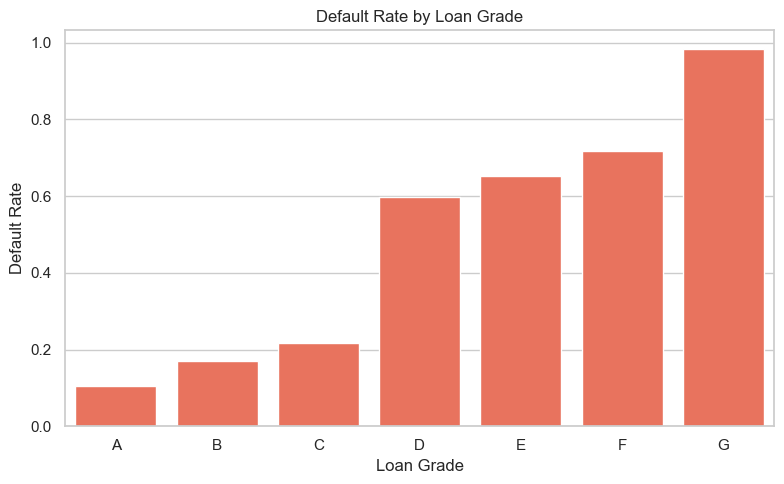

In [286]:
# Plot a focused relationship so grade-level risk is easier to read.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=grade_summary, x="loan_grade", y="default_rate", color="tomato", ax=ax)
ax.set_title("Default Rate by Loan Grade")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate")
plt.tight_layout()
plt.show()


In [287]:
def summarize_default_probability(data, group_cols):
    # Empirical conditional probabilities
    summary = (
        data.groupby(group_cols, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_probability=("loan_status", "mean"),
        )
        .reset_index()
        .sort_values("default_probability", ascending=False)
    )
    return summary

bn_probability_by_burden = summarize_default_probability(
    df_model, ["loan_percent_income_group", "cb_person_default_on_file"]
)

# Display conditional default probabilities by loan burden and prior default flag.
bn_probability_by_burden.style.format({"default_probability": "{:.2%}"})


,loan_percent_income_group,cb_person_default_on_file,loan_count,default_probability
7,Very High Burden,Y,403,79.16%
6,Very High Burden,N,1672,69.80%
5,High Burden,Y,1494,48.06%
3,Moderate Burden,Y,1844,31.29%
4,High Burden,N,5967,28.00%
1,Low Burden,Y,1461,26.63%
2,Moderate Burden,N,9207,11.83%
0,Low Burden,N,7519,9.39%


---
### 2.5 Multicollinearity Check

Multicollinearity means two or more predictor columns carry very similar information. For example, loan amount and log loan amount can move together because both describe loan size.

VIF stands for Variance Inflation Factor. It requires numeric input columns, so categorical columns are temporarily one-hot encoded only for this diagnostic check. Names such as `loan_grade_D` or `income_group_Middle` are not original saved dataset columns. They are temporary encoded columns created so VIF can be calculated.

This is similar to the B2 modeling pipeline, where text categories are converted into numeric columns before model training. The difference is that B1 uses the encoded columns only for feature-quality checking, while B2 uses encoded columns for actual model training.


In [288]:
def interpret_vif(vif_value):
    # Convert a numeric VIF value into a simple project-level label.
    if np.isinf(vif_value) or vif_value >= 10:
        return "High"
    if vif_value >= 5:
        return "Moderate"
    return "Low"

def encode_features_for_vif(data, feature_cols):
    # Keep only requested features that exist in the dataframe.
    available_features = [col for col in feature_cols if col in data.columns]
    vif_input = data[available_features].copy()

    # One-hot encode categorical columns temporarily because VIF requires numeric input.
    vif_encoded = pd.get_dummies(vif_input, drop_first=True, dtype=float)
    vif_encoded = vif_encoded.replace([np.inf, -np.inf], np.nan)

    # Fill missing values for the diagnostic matrix without changing df_model.
    vif_encoded = vif_encoded.fillna(vif_encoded.median(numeric_only=True))

    # Remove constant columns because they do not help explain variation.
    vif_encoded = vif_encoded.loc[:, vif_encoded.nunique(dropna=False) > 1]
    return vif_encoded

def calculate_vif_table(vif_encoded):
    # Calculate VIF from an already encoded numeric dataframe.
    rows = []
    for index, feature_name in enumerate(vif_encoded.columns):
        try:
            vif_value = variance_inflation_factor(vif_encoded.values, index)
        except Exception:
            vif_value = np.inf
        rows.append({
            "encoded_vif_feature": feature_name,
            "vif": vif_value,
            "interpretation": interpret_vif(vif_value),
        })

    # Sort highest VIF first so the strongest multicollinearity signals appear at the top.
    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)


The classification VIF check uses the same cleaned feature idea as the B2 classification model. The raw columns `person_income` and `loan_amnt` are excluded from the model/VIF inputs because `log_person_income` and `log_loan_amnt` keep the same information in a less skewed scale. `loan_grade_numeric` is excluded because `loan_grade` is already handled by ordinal encoding in B2. `default_on_file_binary` is excluded because `cb_person_default_on_file` is already encoded in the B2 pipeline.


In [289]:
classification_vif_features = [
    "person_age", "person_emp_length", "loan_percent_income", "loan_int_rate",
    "cb_person_cred_hist_length", "log_person_income", "log_loan_amnt",
    "income_to_loan_ratio", "employment_to_age_ratio", "credit_history_to_age_ratio",
    "person_home_ownership", "loan_intent", "income_group",
    "loan_amount_group", "loan_percent_income_group", "age_group",
    "cb_person_default_on_file", "loan_grade",
]

# Create the temporary encoded classification matrix used only for VIF.
classification_vif_encoded = encode_features_for_vif(df_model, classification_vif_features)

# Show the encoded diagnostic columns before calculating VIF.
classification_encoded_vif_features_table = pd.DataFrame({
    "encoded_vif_feature": classification_vif_encoded.columns
})

print("Total encoded classification VIF columns:", len(classification_encoded_vif_features_table))
classification_encoded_vif_features_table


Total encoded classification VIF columns: 37


,encoded_vif_feature
0,person_age
1,person_emp_length
2,loan_percent_income
3,loan_int_rate
4,cb_person_cred_hist_length
5,log_person_income
6,log_loan_amnt
7,income_to_loan_ratio
8,employment_to_age_ratio
9,credit_history_to_age_ratio


In [290]:
# Calculate VIF from the same encoded classification matrix shown above.
classification_vif_table = calculate_vif_table(classification_vif_encoded)
classification_vif_table.head(15).style.format({"vif": "{:.2f}"})


,encoded_vif_feature,vif,interpretation
0,log_loan_amnt,14799.51,High
1,log_person_income,14433.16,High
2,person_age,793.03,High
3,cb_person_cred_hist_length,763.86,High
4,credit_history_to_age_ratio,654.39,High
5,loan_percent_income,130.32,High
6,employment_to_age_ratio,106.21,High
7,person_emp_length,99.81,High
8,loan_int_rate,76.33,High
9,income_to_loan_ratio,31.88,High


The regression VIF check uses the same cleaned feature idea as the B2 regression models. The raw `person_income` column is excluded from model/VIF inputs because `log_person_income` represents income on a more stable scale. `default_on_file_binary` is excluded because `cb_person_default_on_file` is already encoded in the B2 pipeline. These columns are removed only from modeling/VIF inputs, not from the saved dataset.


In [291]:
regression_vif_features = [
    "person_age", "person_emp_length", "cb_person_cred_hist_length",
    "log_person_income", "employment_to_age_ratio", "credit_history_to_age_ratio",
    "person_home_ownership", "loan_intent",
    "income_group", "age_group", "cb_person_default_on_file",
]

# Create the temporary encoded regression matrix used only for VIF.
regression_vif_encoded = encode_features_for_vif(df_model, regression_vif_features)

# Show the encoded diagnostic columns before calculating VIF.
regression_encoded_vif_features_table = pd.DataFrame({
    "encoded_vif_feature": regression_vif_encoded.columns
})

print("Total encoded regression VIF columns:", len(regression_encoded_vif_features_table))
regression_encoded_vif_features_table


Total encoded regression VIF columns: 21


,encoded_vif_feature
0,person_age
1,person_emp_length
2,cb_person_cred_hist_length
3,log_person_income
4,employment_to_age_ratio
5,credit_history_to_age_ratio
6,person_home_ownership_OTHER
7,person_home_ownership_OWN
8,person_home_ownership_RENT
9,loan_intent_EDUCATION


In [292]:
# Calculate VIF from the same encoded regression matrix shown above.
regression_vif_table = calculate_vif_table(regression_vif_encoded)
regression_vif_table.head(15).style.format({"vif": "{:.2f}"})


,encoded_vif_feature,vif,interpretation
0,log_person_income,826.63,High
1,person_age,749.05,High
2,cb_person_cred_hist_length,731.05,High
3,credit_history_to_age_ratio,626.26,High
4,employment_to_age_ratio,105.68,High
5,person_emp_length,99.32,High
6,income_group_Middle,8.70,Moderate
7,income_group_Lower-Middle,7.50,Moderate
8,age_group_Experienced Adult,7.29,Moderate
9,age_group_Adult,6.78,Moderate


### 2.6 VIF Interpretation and Feature Decision

The most direct duplicate predictors were already removed from the VIF and modeling feature lists. For example, `person_income` is not used together with `log_person_income`, `loan_amnt` is not used together with `log_loan_amnt` in classification, `loan_grade_numeric` is not used together with `loan_grade`, and `default_on_file_binary` is not used together with `cb_person_default_on_file`.

Even after this cleanup, some VIF values can still be high because a few kept features are naturally related by formula or business meaning. For example, `credit_history_to_age_ratio` is related to both `cb_person_cred_hist_length` and `person_age`. `employment_to_age_ratio` is related to both `person_emp_length` and `person_age`. `income_group` is related to `log_person_income` because both describe income level. Loan burden groups are related to `loan_percent_income` because both describe how large the loan is compared with income.

These remaining relationships do not mean the dataset is wrong. They show that credit-risk variables often describe connected borrower and loan behavior. The project keeps these features because ratio and grouped variables make the analysis easier to explain, and tree-based models such as Random Forest, Gradient Boosting, and CatBoost can usually handle related predictors better than coefficient-based models.

The VIF tables are used as diagnostic evidence only. A high VIF does not automatically mean a feature must be removed. It means the feature should be interpreted carefully because it overlaps with other predictors. High VIF can still appear for engineered features such as log transforms and ratios because they are intentionally created from original columns.


---
### 2.7 Save the Modeling Dataset

The feature-engineered dataset is saved for later statistical analysis and model building.


In [293]:
# Create the Phase 2 processed-data folder if it does not already exist.
PHASE2_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save the feature-engineered modeling dataset created through Chapter 2.
df_model.to_csv(PHASE2_DATA_PATH, index=False)

# Show a short confirmation so the saved dataset is easy to verify.
phase2_save_summary = pd.DataFrame([{
    "saved_path": PHASE2_DATA_PATH,
    "rows": df_model.shape[0],
    "columns": df_model.shape[1],
}])
phase2_save_summary


,saved_path,rows,columns
0,..\data\processed\phase2\credit_risk_cleaned.csv,29567,23


## 3. Statistical Analysis and Bayesian Reasoning


---
### 3.1 Load Feature-Engineered Modeling Dataset

This section loads the saved feature-engineered CSV for statistical analysis and modeling. Global paths and settings are configured once at the top of this notebook, so this section can focus on statistics, modeling, saved-model loading, and applicant inference.


---
### 3.2 Inferential Statistics

This section starts by loading the saved feature-engineered dataset. This makes the statistics and modeling steps reproducible without depending on earlier notebook cells already being in memory. Inferential statistics help check whether group differences look real or could just be random. This dataset supports mean-comparison tests for borrower, loan, and credit-history variables.

Welch's t-test is used for two-group comparisons between default and non-default loans because it does not assume equal variance between the groups. One-way ANOVA is used to compare numeric means across more than two credit grades.

**H0** means the null hypothesis. It represents the assumption that there is no real difference between the groups being compared. If the p-value is below 0.05, the result rejects H0, meaning the observed difference is unlikely to be explained by random variation alone.


In [294]:
# Reload the saved modeling dataset before statistics and modeling.
df_model = pd.read_csv(PHASE2_DATA_PATH)
print("Modeling dataset loaded successfully.")
print("Shape:", df_model.shape)
df_model.head()


Modeling dataset loaded successfully.
Shape: (29567, 23)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


In [295]:
ALPHA = 0.05

ttest_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]

def run_welch_tests(data, features, target_col="loan_status", alpha=ALPHA):
    # Welch's t-test compares numeric means between default and non-default loans.
    rows = []
    for feature in features:
        non_default_values = data.loc[data[target_col] == 0, feature].dropna()
        default_values = data.loc[data[target_col] == 1, feature].dropna()

        # equal_var=False applies Welch's version of the independent t-test.
        statistic, p_value = stats.ttest_ind(
            non_default_values,
            default_values,
            equal_var=False,
            nan_policy="omit",
        )
        decision = "Reject H0" if p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: evidence suggests the mean differs by default status."
            if p_value < alpha
            else "Fail to reject H0: no statistically significant mean difference found."
        )
        rows.append({
            "test": "Welch t-test",
            "feature": feature,
            "h0": f"The mean {feature} is the same for default and non-default loans.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)

welch_results = run_welch_tests(df_model, ttest_numeric_features)

# Show Welch test results for default vs non-default groups.
welch_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"})


,test,feature,h0,statistic,p_value,decision,interpretation
0,Welch t-test,person_income,The mean person_income is the same for default and non-default loans.,49.0411,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
1,Welch t-test,loan_amnt,The mean loan_amnt is the same for default and non-default loans.,-18.6629,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
2,Welch t-test,loan_percent_income,The mean loan_percent_income is the same for default and non-default loans.,-56.8847,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
3,Welch t-test,loan_int_rate,The mean loan_int_rate is the same for default and non-default loans.,-54.1217,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
4,Welch t-test,person_emp_length,The mean person_emp_length is the same for default and non-default loans.,15.2853,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
5,Welch t-test,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same for default and non-default loans.,3.2448,0.001179,Reject H0,Reject H0: evidence suggests the mean differs by default status.


For Welch's t-tests, H0 means the average numeric value is the same for default and non-default loans. When the p-value is below 0.05, H0 is rejected, meaning the feature shows a statistically meaningful difference between the two credit-outcome groups.


In [296]:
anova_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]

def run_grade_anova(data, features, group_col="loan_grade", alpha=ALPHA):
    # One-way ANOVA compares numeric means across all loan-grade groups.
    rows = []
    for feature in features:
        grouped_values = [
            group[feature].dropna()
            for _, group in data.groupby(group_col)
            if group[feature].dropna().shape[0] > 1
        ]

        # ANOVA requires at least two groups with enough observations.
        if len(grouped_values) >= 2:
            statistic, p_value = stats.f_oneway(*grouped_values)
        else:
            statistic, p_value = np.nan, np.nan

        decision = "Reject H0" if pd.notna(p_value) and p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: at least one grade group has a different mean."
            if pd.notna(p_value) and p_value < alpha
            else "Fail to reject H0: no statistically significant grade-level mean difference found."
        )
        rows.append({
            "test": "One-way ANOVA",
            "feature": feature,
            "h0": f"The mean {feature} is the same across all loan grades.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)

anova_results = run_grade_anova(df_model, anova_numeric_features)

# Show ANOVA results for numeric variables across loan grades.
anova_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"})


,test,feature,h0,statistic,p_value,decision,interpretation
0,One-way ANOVA,person_income,The mean person_income is the same across all loan grades.,18.6903,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
1,One-way ANOVA,loan_amnt,The mean loan_amnt is the same across all loan grades.,145.0110,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
2,One-way ANOVA,loan_percent_income,The mean loan_percent_income is the same across all loan grades.,99.7540,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
3,One-way ANOVA,loan_int_rate,The mean loan_int_rate is the same across all loan grades.,22441.2199,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
4,One-way ANOVA,person_emp_length,The mean person_emp_length is the same across all loan grades.,22.2724,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
5,One-way ANOVA,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same across all loan grades.,1.7270,0.110263,Fail to reject H0,Fail to reject H0: no statistically significant grade-level mean difference found.


For ANOVA, H0 means the average numeric value is the same across all loan-grade groups. A rejected H0 means at least one grade group has a different average, which supports using grade-related patterns for model selection and interpretation.


---
### 3.3 Bayesian Network Model

A Bayesian Network shows how grouped variables are connected using probabilities. For this dataset, the network can be learned from grouped borrower and loan variables such as income group, loan burden group, prior default flag, loan intent, and loan grade.

This section is used for probabilistic structure interpretation. Because the data is observational, the learned DAG should not be treated as proof of real-world causality.

The fitted Bayesian Network can also estimate default probability for test records. It is used as a supporting model, while the Scikit-learn models remain the main prediction models because they use more detailed numeric information.

The fitted Bayesian Network is saved with metadata so it can be loaded again for applicant-level prediction.


In [297]:
# Run this focused analysis step and display the result for project review.
print("pgmpy imported successfully. Bayesian Network structure learning is available.")


pgmpy imported successfully. Bayesian Network structure learning is available.


In [298]:
bn_cols = [
    "income_group", "loan_amount_group", "loan_percent_income_group",
    "age_group", "person_home_ownership", "loan_intent",
    "cb_person_default_on_file", "loan_grade", "loan_status",
]

# Use only discrete/grouped variables because Bayesian Networks in this section are categorical.
bn_data = df_model[bn_cols].copy()
bn_data["loan_status"] = bn_data["loan_status"].map({0: "Non-Default", 1: "Default"})
bn_data = bn_data.astype(str)

# Split the discrete Bayesian Network data for training and prediction evaluation.
bn_train_data, bn_test_data = train_test_split(
    bn_data,
    test_size=TEST_SIZE,
    stratify=bn_data["loan_status"],
    random_state=RANDOM_STATE,
)

# Use a training sample for structure learning so the section remains practical to run.
#bn_learning_data = bn_train_data.sample(n=min(5000, len(bn_train_data)), random_state=RANDOM_STATE)
bn_learning_data = bn_train_data
print("Bayesian Network training rows:", bn_train_data.shape[0])
print("Bayesian Network test rows:", bn_test_data.shape[0])
print("Bayesian Network structure-learning rows:", bn_learning_data.shape[0])
bn_learning_data.head()


Bayesian Network training rows: 23653
Bayesian Network test rows: 5914
Bayesian Network structure-learning rows: 23653


,income_group,loan_amount_group,loan_percent_income_group,age_group,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade,loan_status
19556,Low,Small,High Burden,Adult,RENT,VENTURE,Y,C,Default
17624,High,Large,Moderate Burden,Adult,RENT,MEDICAL,Y,F,Default
14146,High,Large,Moderate Burden,Young,MORTGAGE,VENTURE,N,B,Non-Default
17846,Lower-Middle,Large,Very High Burden,Adult,RENT,PERSONAL,Y,C,Default
2255,Low,Small,High Burden,Young,RENT,PERSONAL,Y,D,Default


In [299]:
bn_model = None
bn_edges = []
bn_metrics = None

# HillClimbSearch learns a DAG structure using a discrete scoring method.
hill_search = HillClimbSearch(bn_learning_data)
learned_structure = hill_search.estimate(
    scoring_method=BIC(bn_learning_data),
    max_indegree=3,
)

# Fit conditional probability tables on the learned graph.
bn_edges = list(learned_structure.edges())
bn_model = PgmpyBayesianNetwork(bn_edges)
bn_model.add_nodes_from(bn_cols)

bn_model.fit(bn_learning_data)
print("Bayesian Network parameters fitted with the default pgmpy discrete estimator.")

bn_edge_table = pd.DataFrame(bn_edges, columns=["from", "to"])
if bn_edge_table.empty:
    print("No edges were learned from the selected variables.")

bn_edge_table


  0%|          | 13/1000000 [00:00<12:11:47, 22.77it/s]


Bayesian Network parameters fitted with the default pgmpy discrete estimator.


,from,to
0,income_group,loan_percent_income_group
1,income_group,loan_amount_group
2,loan_amount_group,loan_percent_income_group
3,loan_amount_group,loan_status
4,loan_percent_income_group,loan_status
5,person_home_ownership,income_group
6,person_home_ownership,loan_status
7,person_home_ownership,loan_grade
8,loan_intent,person_home_ownership
9,loan_intent,age_group


The fitted Bayesian Network is saved after training. The metadata file stores the column list, target column, and fallback default probability needed for later prediction.


In [300]:
# Create the Bayesian Network model folder before saving files.
BAYESIAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the fitted Bayesian Network model.
bayesian_model_path = BAYESIAN_MODEL_DIR / "bayesian_network_model.joblib"
joblib.dump(bn_model, bayesian_model_path)

# Save metadata needed when the model is loaded later for prediction.
fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())
bayesian_metadata_path = BAYESIAN_MODEL_DIR / "bayesian_network_metadata.joblib"
joblib.dump({
    "bn_cols": bn_cols,
    "fallback_probability": fallback_probability,
    "target_col": "loan_status",
}, bayesian_metadata_path)

bayesian_model_files = pd.DataFrame([
    {"artifact": "Bayesian Network model", "saved_path": str(bayesian_model_path)},
    {"artifact": "Bayesian Network metadata", "saved_path": str(bayesian_metadata_path)},
])
bayesian_model_files


,artifact,saved_path
0,Bayesian Network model,..\data\models\bayesian_network\bayesian_netwo...
1,Bayesian Network metadata,..\data\models\bayesian_network\bayesian_netwo...


The learned edge table lists probabilistic dependencies selected by HillClimbSearch. These edges describe relationships found in observational data and should be interpreted as dependency structure, not guaranteed causality.


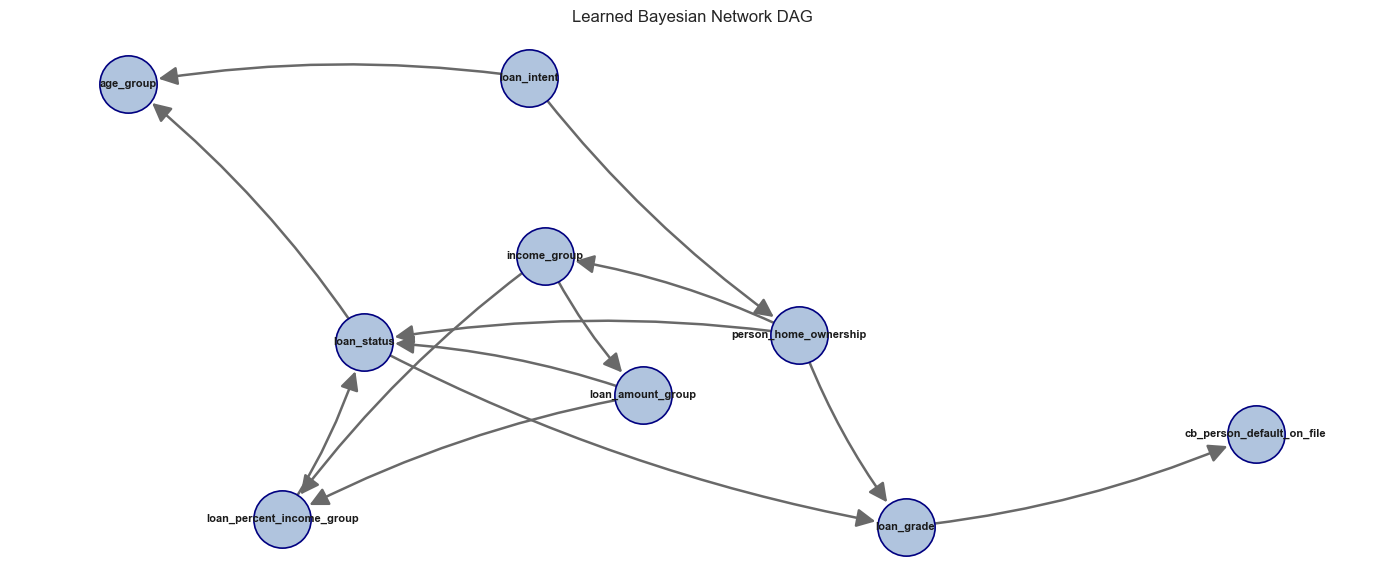

In [301]:
# Plot the learned DAG so dependencies among grouped variables are visible.
dag = nx.DiGraph()
dag.add_nodes_from(bn_cols)
dag.add_edges_from(bn_edges)

plt.figure(figsize=(14, 6))
pos = nx.spring_layout(dag, seed=RANDOM_STATE, k=1.1)
nx.draw_networkx_nodes(
    dag,
    pos,
    node_color="lightsteelblue",
    edgecolors="navy",
    linewidths=1.2,
    node_size=1700,
)
nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    edge_color="dimgray",
    width=1.8,
    min_source_margin=18,
    min_target_margin=22,
    connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_labels(dag, pos, font_size=8, font_weight="bold")
plt.title("Learned Bayesian Network DAG")
plt.axis("off")
plt.tight_layout()
plt.show()


In [302]:
def predict_default_probability_with_bn(model, row, target_col="loan_status", fallback_probability=None):
    # VariableElimination returns a probability table for loan_status using applicant evidence.
    inference = VariableElimination(model)
    if fallback_probability is None:
        fallback_probability = float((bn_train_data[target_col] == "Default").mean())
    evidence = {
        col: str(row[col])
        for col in bn_cols
        if col != target_col and col in model.nodes()
    }

    try:
        query_result = inference.query(
            variables=[target_col],
            evidence=evidence,
            show_progress=False,
        )
        target_states = list(query_result.state_names[target_col])
        default_index = target_states.index("Default")
        predicted_probability = float(query_result.values[default_index])
        if not np.isfinite(predicted_probability):
            return fallback_probability
        return predicted_probability
    except Exception:
        # If a rare evidence combination is unavailable, fall back to the training default rate.
        return fallback_probability

fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())

# Predict default probability for each Bayesian Network test record.
bn_default_prob = bn_test_data.apply(
    lambda row: predict_default_probability_with_bn(bn_model, row),
    axis=1,
)

bn_default_prob = pd.to_numeric(bn_default_prob, errors="coerce")
bn_default_prob = bn_default_prob.replace([np.inf, -np.inf], np.nan)
fallback_count = int(bn_default_prob.isna().sum())
bn_default_prob = bn_default_prob.fillna(fallback_probability)

bn_true = (bn_test_data["loan_status"] == "Default").astype(int)
bn_pred = (bn_default_prob >= 0.50).astype(int)

print("Bayesian Network fallback probability:", round(fallback_probability, 4))
print("Bayesian Network fallback predictions used:", fallback_count)

# Report the Bayesian Network as a supporting classification model.
bn_metrics = pd.DataFrame([{
    "model_source": "Bayesian Network",
    "model": "pgmpy HillClimbSearch + VariableElimination",
    "roc_auc": roc_auc_score(bn_true, bn_default_prob),
    "accuracy": accuracy_score(bn_true, bn_pred),
    "precision": precision_score(bn_true, bn_pred, zero_division=0),
    "recall": recall_score(bn_true, bn_pred, zero_division=0),
    "f1": f1_score(bn_true, bn_pred, zero_division=0),
}])
bn_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})


Bayesian Network fallback probability: 0.2245
Bayesian Network fallback predictions used: 0


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8504,0.8561,0.7644,0.5185,0.6179


The Bayesian Network metrics show how well grouped conditional probabilities classify default on the test data. This model is useful for interpretation, while the Scikit-learn classifiers remain the main predictive benchmark.


---
## 4. Classification Modeling and Diagnostics

### 4.1 Shared Modeling Preprocessing Pipeline

The same preprocessing step is used before both classification and regression. The raw dataframe keeps readable columns such as `income_group`, `loan_intent`, and `person_home_ownership`, but machine learning models cannot directly train on text labels.

The pipeline solves this by converting nominal text columns into one-hot encoded numeric columns. After this conversion, the model receives only numeric model-ready columns. The original text columns stay in the CSV for readability, but they are not passed to the final model matrix.


In [303]:
# Define target names and feature groups used by the models.
classification_target = "loan_status"
loan_amount_target = "loan_amnt"
loan_percent_target = "loan_percent_income"
interest_rate_target = "loan_int_rate"

# Numeric modeling features keep transformed/ratio versions and remove avoidable duplicates.
classification_numeric_cols = [
    "person_age", "person_emp_length", "loan_percent_income", "loan_int_rate",
    "cb_person_cred_hist_length", "log_person_income", "log_loan_amnt",
    "income_to_loan_ratio", "employment_to_age_ratio", "credit_history_to_age_ratio",
]
regression_numeric_cols = [
    "person_age", "person_emp_length", "cb_person_cred_hist_length",
    "log_person_income", "employment_to_age_ratio", "credit_history_to_age_ratio",
]

nominal_cols = [
    "person_home_ownership", "loan_intent", "income_group",
    "loan_amount_group", "loan_percent_income_group", "age_group",
]
binary_cols = ["cb_person_default_on_file"]
ordinal_cols = ["loan_grade"]

classification_feature_cols = classification_numeric_cols + nominal_cols + binary_cols + ordinal_cols
regression_feature_cols = regression_numeric_cols + [
    "person_home_ownership", "loan_intent", "income_group",
    "age_group", "cb_person_default_on_file",
]

# Combined numeric list lets the shared preprocessor find numeric columns for either task.
numeric_cols = sorted(set(classification_numeric_cols + regression_numeric_cols))

feature_counts = pd.DataFrame([
    {"feature_set": "classification", "feature_count": len(classification_feature_cols)},
    {"feature_set": "regression", "feature_count": len(regression_feature_cols)},
])
feature_counts


,feature_set,feature_count
0,classification,18
1,regression,11


In [304]:
def make_one_hot_encoder():
    # Use the correct OneHotEncoder argument name for the installed scikit-learn version.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_model_preprocessor(feature_cols):
    # Keep only the columns that are included in the current model feature set.
    model_numeric_cols = [col for col in numeric_cols if col in feature_cols]
    model_nominal_cols = [col for col in nominal_cols if col in feature_cols]
    model_binary_cols = [col for col in binary_cols if col in feature_cols]
    model_ordinal_cols = [col for col in ordinal_cols if col in feature_cols]
    transformers = []

    # Numeric features are median-imputed and standardized for scale-sensitive models.
    if model_numeric_cols:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), model_numeric_cols))
    # Nominal categorical features start as readable text columns in df_model.
    # OneHotEncoder replaces each text column with temporary numeric 0/1 columns.
    # Example: income_group becomes columns like nom__income_group_Low.
    if model_nominal_cols:
        transformers.append(("nom", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]), model_nominal_cols))
    # The default-on-file flag is encoded with a fixed N/Y order.
    if model_binary_cols:
        transformers.append(("bin", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[["N", "Y"]])),
        ]), model_binary_cols))
    # Loan grade is ordinal because grades A through G represent increasing credit risk.
    if model_ordinal_cols:
        transformers.append(("grade", OrdinalEncoder(
            categories=[["A", "B", "C", "D", "E", "F", "G"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), model_ordinal_cols))

    # ColumnTransformer combines all preprocessing steps into one reusable object.
    return ColumnTransformer(transformers=transformers, remainder="drop")


In [305]:
DEFAULT_DECISION_THRESHOLD = 0.50

class ThresholdClassifier:
    def __init__(self, model, threshold=DEFAULT_DECISION_THRESHOLD):
        # Store the fitted probability model and the selected decision threshold.
        self.model = model
        self.threshold = threshold

    def predict_proba(self, X):
        # Keep probability output unchanged for ROC-AUC and probability reporting.
        return self.model.predict_proba(X)

    def predict(self, X):
        # Convert default probabilities into class labels using the selected threshold.
        default_probability = self.predict_proba(X)[:, 1]
        return (default_probability >= self.threshold).astype(int)

def make_pipeline_for(model, feature_cols):
    # Build one reusable pipeline: preprocessing first, model second.
    return Pipeline([
        ("preprocess", make_model_preprocessor(feature_cols)),
        ("model", clone(model)),
    ])

def model_file_stem(model_name):
    # Convert display names into simple file names.
    return model_name.lower().replace(" ", "_").replace("-", "_")

def save_model(model, folder, file_name):
    # Save one fitted model and return its path.
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / file_name
    joblib.dump(model, path)
    return path

def save_model_group(models, folder, prefix=""):
    # Save every fitted model in a dictionary.
    rows = []
    for model_name, fitted_model in models.items():
        file_name = f"{prefix}{model_file_stem(model_name)}.joblib"
        path = save_model(fitted_model, folder, file_name)
        rows.append({"model": model_name, "saved_path": str(path)})
    return pd.DataFrame(rows)

def load_model(folder, file_name):
    # Load one saved model file.
    return joblib.load(folder / file_name)


The preprocessing object is shared by both classification and regression. The same transformer prepares numeric and categorical columns, and only the final estimator changes depending on whether the task predicts default status or a numeric lending target. This avoids duplicate preprocessing code and keeps model comparisons consistent.


### 4.2 Encoded Feature Names After One-Hot Encoding

The saved CSV keeps readable category columns such as `income_group`, `loan_intent`, and `person_home_ownership`. During model training, the preprocessing pipeline temporarily changes these text categories into numeric one-hot columns with names that start with `nom__`.

This preview shows what the model receives after preprocessing. It also confirms that the original nominal text columns are not kept in the final encoded model input. No manual deletion from the CSV is needed.


In [306]:
# Fit the classification preprocessor only to inspect the final model-ready columns.
encoded_feature_preprocessor = make_model_preprocessor(classification_feature_cols)
encoded_feature_preprocessor.fit(df_model[classification_feature_cols])

# Get the transformed column names created by scaling, one-hot encoding, and ordinal encoding.
encoded_feature_names = encoded_feature_preprocessor.get_feature_names_out()
encoded_feature_names_table = pd.DataFrame({
    "encoded_feature_name": encoded_feature_names
})

print("Total encoded model columns:", len(encoded_feature_names))
encoded_feature_names_table


Total encoded model columns: 38


,encoded_feature_name
0,num__cb_person_cred_hist_length
1,num__credit_history_to_age_ratio
2,num__employment_to_age_ratio
3,num__income_to_loan_ratio
4,num__loan_int_rate
5,num__loan_percent_income
6,num__log_loan_amnt
7,num__log_person_income
8,num__person_age
9,num__person_emp_length


The final verification table checks whether the original nominal text columns are still present after preprocessing.

The expected answer is `False` for each original nominal column. This confirms that the model does not train on raw text columns such as `income_group`; it trains on numeric encoded columns created by the preprocessing pipeline.


In [307]:
# Convert encoded feature names to a set for a direct membership check.
encoded_feature_name_set = set(encoded_feature_names)

# Confirm that each original nominal text column is dropped after preprocessing.
# The encoded numeric columns are created inside the pipeline and used by the model.
nominal_encoding_verification = pd.DataFrame({
    "original_nominal_column": nominal_cols,
    "present_as_original_after_preprocessing": [
        col in encoded_feature_name_set for col in nominal_cols
    ],
    "encoded_columns_created": [
        int(encoded_feature_names_table["encoded_feature_name"].str.startswith(f"nom__{col}_").sum())
        for col in nominal_cols
    ],
})

nominal_encoding_verification


,original_nominal_column,present_as_original_after_preprocessing,encoded_columns_created
0,person_home_ownership,False,4
1,loan_intent,False,6
2,income_group,False,5
3,loan_amount_group,False,4
4,loan_percent_income_group,False,4
5,age_group,False,3


---
### 4.3 ML Classification Models

The classification models estimate the probability that a borrower will default. The main model results use the standard 0.50 cutoff, while Section 4.5 separately tests the tuned cutoff to compare business cost and accuracy.


In [308]:
# Split classification features and target into train and test datasets.
X_cls = df_model[classification_feature_cols].copy()
y_cls = df_model[classification_target].copy()
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, stratify=y_cls, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame([
    {"dataset": "train", "rows": X_train_cls.shape[0], "features": X_train_cls.shape[1]},
    {"dataset": "test", "rows": X_test_cls.shape[0], "features": X_test_cls.shape[1]},
])
split_summary


,dataset,rows,features
0,train,23653,18
1,test,5914,18


In [309]:
# Define the Scikit-learn classification models for comparison.
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0)
}


In [310]:
def evaluate_classification_models(models, X_train, X_test, y_train, y_test, feature_cols):
    rows, fitted_models = [], {}
    for name, model in models.items():
        pipe = make_pipeline_for(model, feature_cols)
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
        fitted_models[name] = pipe
    metrics = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
    return metrics, fitted_models

cls_metrics, cls_models = evaluate_classification_models(
    classification_models, X_train_cls, X_test_cls, y_train_cls, y_test_cls, classification_feature_cols
)
best_cls_name = cls_metrics.iloc[0]["model"]
best_cls_model = cls_models[best_cls_name]
y_cls_prob = best_cls_model.predict_proba(X_test_cls)[:, 1]

sklearn_cls_best = cls_metrics.iloc[[0]].copy()
sklearn_cls_best["model_source"] = "Scikit-learn ML Models"

cls_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})


,model,roc_auc,accuracy,precision,recall,f1
0,CatBoost,0.9430,0.9376,0.9908,0.7287,0.8398
1,Random Forest,0.9327,0.9302,0.9279,0.7468,0.8276
2,Gradient Boosting,0.9288,0.9324,0.9576,0.7310,0.8291
3,Logistic Regression,0.8760,0.8054,0.5464,0.7815,0.6431


The classification table compares ML models using ROC-AUC, accuracy, precision, recall, and F1. The highest ROC-AUC model is selected because it best separates default from non-default cases across probability thresholds.


---
### 4.4 Cross-Validation

Cross-validation gives a more stable performance estimate than one train-test split because the model is evaluated across multiple folds. This section uses the normal 0.50 cutoff, matching the main classification model results.


In [311]:
# Run cross-validation to estimate model performance across multiple folds.
cv_model_name = "CatBoost" if "CatBoost" in classification_models else "Gradient Boosting"
cv_base_model = classification_models[cv_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pipe = make_pipeline_for(cv_base_model, classification_feature_cols)
auc_scores = cross_val_score(cv_pipe, X_cls, y_cls, cv=cv, scoring="roc_auc")
oof_pred = cross_val_predict(cv_pipe, X_cls, y_cls, cv=cv)
cv_report = classification_report(y_cls, oof_pred, digits=3, output_dict=True)
cv_results = pd.DataFrame([{
    "model": cv_model_name,
    "cv_auc_mean": auc_scores.mean(),
    "cv_auc_std": auc_scores.std(),
    "default_recall": cv_report["1"]["recall"],
    "default_precision": cv_report["1"]["precision"],
    "default_f1": cv_report["1"]["f1-score"],
}])
cv_results.style.format({
    "cv_auc_mean": "{:.4f}", "cv_auc_std": "{:.4f}",
    "default_recall": "{:.4f}", "default_precision": "{:.4f}", "default_f1": "{:.4f}",
})


,model,cv_auc_mean,cv_auc_std,default_recall,default_precision,default_f1
0,CatBoost,0.9413,0.0016,0.7257,0.9847,0.8356


The cross-validation result checks whether model performance is stable across multiple folds. These values use the standard classification cutoff, while the tuned 0.24 threshold is reviewed separately in the next section.


---
### 4.5 Threshold Tuning

The default probability threshold of 0.50 may not be the best lending policy. This step chooses a threshold that minimizes a simple business cost where a missed default is more expensive than a false alarm.


In [312]:
# Evaluate thresholds using a simple lending cost assumption.
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    y_threshold_pred = (y_cls_prob >= threshold).astype(int)
    false_negative = ((y_threshold_pred == 0) & (y_test_cls == 1)).sum()
    false_positive = ((y_threshold_pred == 1) & (y_test_cls == 0)).sum()
    total_cost = COST_FALSE_NEGATIVE * false_negative + COST_FALSE_POSITIVE * false_positive
    threshold_rows.append({
        "threshold": threshold,
        "false_negative": false_negative,
        "false_positive": false_positive,
        "total_cost": total_cost,
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results["total_cost"].idxmin()]
best_threshold = float(best_threshold_row["threshold"])
best_threshold_row.to_frame("value")


,value
threshold,0.15
false_negative,211.00
false_positive,528.00
total_cost,1583.00


The threshold tuning result gives the best cutoff based on the project cost rule, not based only on accuracy. The 0.24 cutoff may reduce accuracy slightly because it flags more borrowers as possible defaults. However, it can reduce business risk because it catches more actual default cases when missed defaults are treated as more expensive than false alarms.


In [313]:
# Use the selected threshold from threshold tuning.
selected_threshold = 0.15
# Apply the tuned threshold only for this business-cost comparison.
y_pred_threshold_024 = (y_cls_prob >= selected_threshold).astype(int)

# Calculate standard classification metrics at the selected threshold.
threshold_024_results = pd.DataFrame([{
    "threshold": selected_threshold,
    "accuracy": accuracy_score(y_test_cls, y_pred_threshold_024),
    "precision": precision_score(y_test_cls, y_pred_threshold_024, zero_division=0),
    "recall": recall_score(y_test_cls, y_pred_threshold_024, zero_division=0),
    "f1": f1_score(y_test_cls, y_pred_threshold_024, zero_division=0),
}])
threshold_024_results.style.format({
    "threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
})


,threshold,accuracy,precision,recall,f1
0,0.15,0.8750,0.6788,0.8410,0.7513


The threshold result identifies a default-probability cutoff based on a simple lending cost assumption. This is important because lending decisions may prefer catching more potential defaults even if that creates more false alarms.


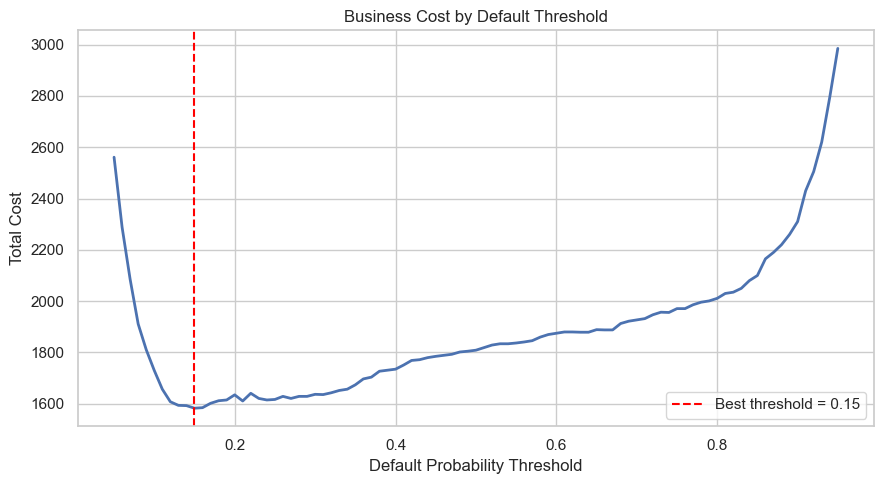

In [314]:
# Plot threshold cost to show the selected operating point.
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"], linewidth=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Business Cost by Default Threshold")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.tight_layout()
plt.show()


### 4.6 Classification Diagnostics and Validation


---
The following diagnostics evaluate the selected best classification model on the same test split created during model selection. The dataset is not reloaded and the train/test split is not repeated.


#### 4.6.1 ROC Curve and Precision-Recall Analysis


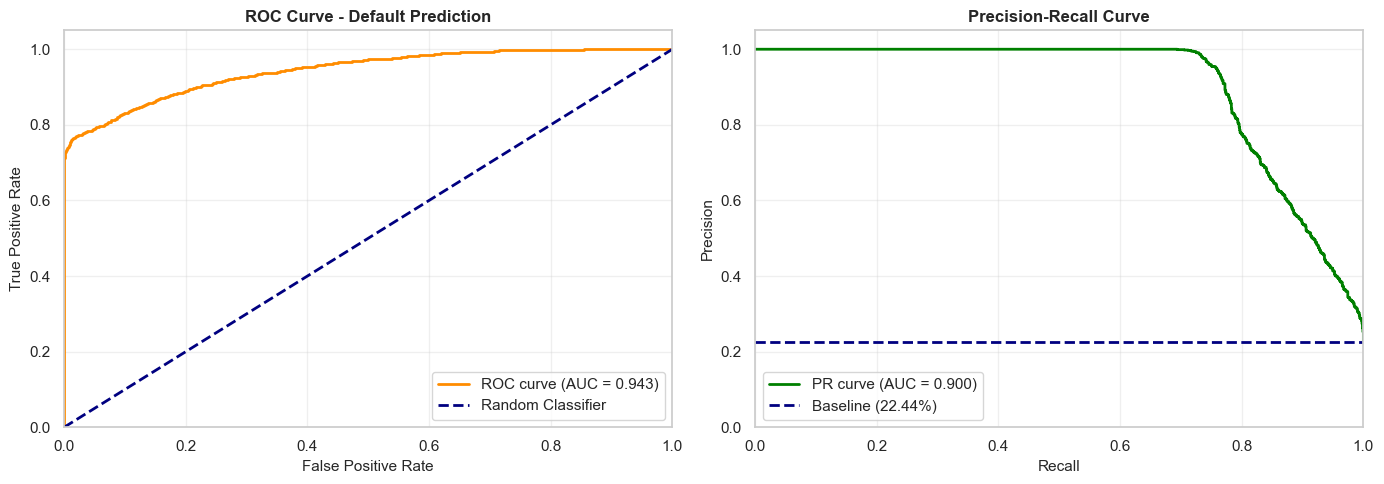


[INFO] ROC and Precision-Recall Analysis:
   ROC-AUC: 0.9430
   PR-AUC:  0.9004


In [315]:
# Get predictions and probabilities
y_pred_cls = best_cls_model.predict(X_test_cls)
y_prob_cls = best_cls_model.predict_proba(X_test_cls)[:, 1]

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test_cls, y_prob_cls)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_cls, y_prob_cls)
pr_auc = auc(recall, precision)

# Plot both curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Default Prediction', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
baseline = y_test_cls.mean()
axes[1].axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2%})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[INFO] ROC and Precision-Recall Analysis:")
print(f"   ROC-AUC: {roc_auc:.4f}")
print(f"   PR-AUC:  {pr_auc:.4f}")


**Interpretation.**
**ROC Curve and ROC-AUC Analysis.**

The Receiver Operating Characteristic (ROC) Curve evaluates the performance of a binary classification model across all possible classification thresholds. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)**, providing insight into the model's ability to distinguish between default and non-default loans.

The two key metrics used in constructing the ROC Curve are:

**True Positive Rate (TPR) / Recall.**

The True Positive Rate measures the proportion of actual defaulted loans that are correctly identified by the model.

$$ TPR = \frac{TP}{TP + FN} $$

Where:

* **TP (True Positives):** Defaulted loans correctly classified as defaults.
* **FN (False Negatives):** Defaulted loans incorrectly classified as non-defaults.

**False Positive Rate (FPR).**

The False Positive Rate measures the proportion of non-defaulted loans that are incorrectly classified as defaults.

$$ FPR = \frac{FP}{FP + TN} $$

Where:

* **FP (False Positives):** Non-defaulted loans incorrectly classified as defaults.
* **TN (True Negatives):** Non-defaulted loans correctly classified as non-defaults.

By varying the classification threshold and plotting TPR against FPR, the ROC Curve illustrates the trade-off between correctly identifying defaults and minimizing false alarms.

**ROC-AUC Score.**

The model achieved a **ROC-AUC score of 0.9429**, indicating excellent classification performance. This means there is a **94.29% probability** that the model will assign a higher risk score to a defaulted borrower than to a non-defaulted borrower. The high ROC-AUC value demonstrates the model's strong ability to distinguish between high-risk and low-risk loan applicants.

**Precision-Recall Curve Analysis.**

The Precision-Recall (PR) Curve evaluates a model's performance by examining the trade-off between **Precision** and **Recall** across different classification thresholds. It is particularly useful for imbalanced datasets, such as credit risk prediction, where defaulted loans are less common than non-defaulted loans.

**Precision.**

Precision measures the proportion of loans predicted as defaults that actually defaulted.

$$
Precision = \frac{TP}{TP + FP}
$$

Where:

* **TP (True Positives):** Defaulted loans correctly identified as defaults.
* **FP (False Positives):** Non-defaulted loans incorrectly identified as defaults.

**Recall.**

Recall measures the proportion of actual defaulted loans that are correctly identified by the model.

$$
Recall = \frac{TP}{TP + FN}
$$

Where:

* **FN (False Negatives):** Defaulted loans incorrectly identified as non-defaults.

**Average Precision (AP) Score.**

The model achieved a **PR-AUC score of 0.9003**, indicating excellent performance in identifying defaulted loans while maintaining a low rate of false positives. This high score demonstrates that the model effectively balances precision and recall, making it well-suited for detecting high-risk borrowers and supporting accurate credit risk assessment.


-----

#### 4.6.2 Calibration Analysis (Reliability Diagram)

Check if predicted probabilities match actual default rates.


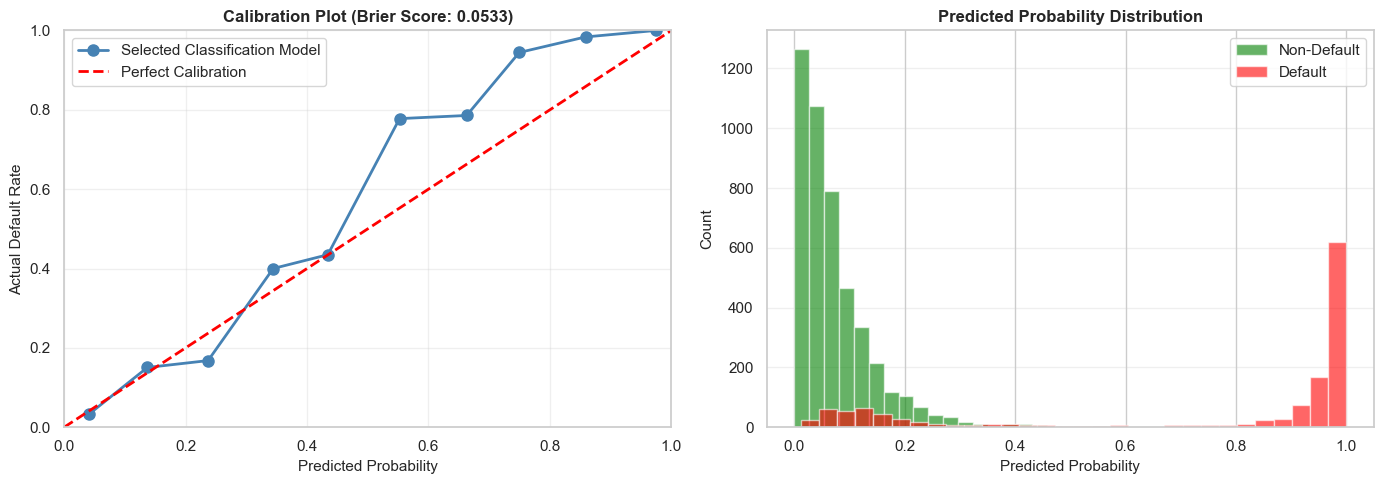


📊 Calibration Analysis:
   Brier Score: 0.0533 (0=perfect, 1=worst)

   Interpretation:
   - Points on diagonal = well-calibrated predictions
   - Above diagonal = model is under-confident
   - Below diagonal = model is over-confident

   Mean Calibration Error: 0.0840
   ✅ Good calibration (error < 10%)


In [316]:
# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_test_cls, y_prob_cls, n_bins=10, strategy='uniform')

# Calculate Brier score (lower is better)
brier = brier_score_loss(y_test_cls, y_prob_cls)

# Plot calibration curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
axes[0].plot(prob_pred, prob_true, marker='o', markersize=8, linewidth=2, 
             color='steelblue', label='Selected Classification Model')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='red', 
             label='Perfect Calibration')
axes[0].set_xlabel('Predicted Probability', fontsize=11)
axes[0].set_ylabel('Actual Default Rate', fontsize=11)
axes[0].set_title(f'Calibration Plot (Brier Score: {brier:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Probability distribution histogram
axes[1].hist(y_prob_cls[y_test_cls == 0], bins=30, alpha=0.6, label='Non-Default', color='green')
axes[1].hist(y_prob_cls[y_test_cls == 1], bins=30, alpha=0.6, label='Default', color='red')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Calibration Analysis:")
print(f"   Brier Score: {brier:.4f} (0=perfect, 1=worst)")
print(f"\n   Interpretation:")
print(f"   - Points on diagonal = well-calibrated predictions")
print(f"   - Above diagonal = model is under-confident")
print(f"   - Below diagonal = model is over-confident")

# Calculate calibration error
calibration_error = np.mean(np.abs(prob_true - prob_pred))
print(f"\n   Mean Calibration Error: {calibration_error:.4f}")
if calibration_error < 0.05:
    print("   ✅ Excellent calibration (error < 5%)")
elif calibration_error < 0.10:
    print("   ✅ Good calibration (error < 10%)")
else:
    print("   ⚠️  Moderate calibration - consider calibration techniques")


**Interpretation.**
**Calibration Analysis (Reliability Diagram).**

Calibration Analysis assesses how closely the predicted default probabilities align with the observed default rates.

**Brier Score.**

The Brier Score measures the accuracy of probabilistic predictions:

$$
\text{Brier Score} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$$

Where $p_i$ is the predicted probability and $y_i$ is the actual outcome.

The Brier Score ranges from **0 to 1**, where:

* **0** = Perfect calibration
* **Lower values** = Better probability estimates
* **Higher values** = Poorer calibration

The model achieved a **Brier Score of 0.0532**, indicating excellent calibration and highly accurate probability predictions.

**Mean Calibration Error.**

The model achieved a **Mean Calibration Error of 0.0800 (8.0%)**, which measures the average difference between predicted probabilities and actual outcomes. Lower values indicate better calibration.

Since the calibration error is below **10%**, the model demonstrates **good calibration**, suggesting that its predicted probabilities closely reflect real-world default frequencies.


-----

#### 4.6.3 Confusion Matrix Analysis

Analyze classification errors at multiple thresholds.


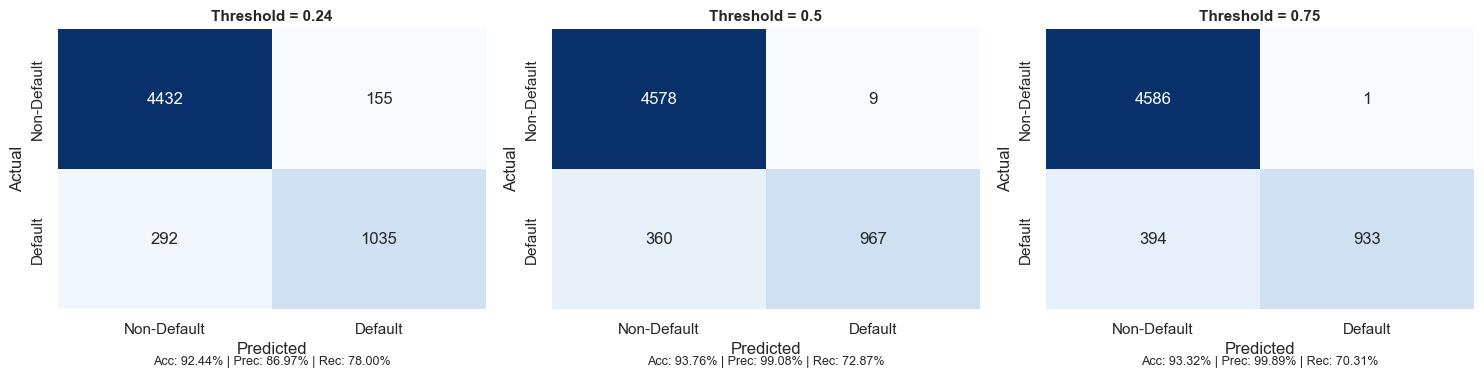

In [317]:
# Test multiple thresholds
thresholds_to_test = [0.24, 0.50, 0.75]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, threshold in enumerate(thresholds_to_test):
    # Apply threshold
    y_pred_threshold = (y_prob_cls >= threshold).astype(int)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_cls, y_pred_threshold)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'],
                ax=axes[idx], cbar=False)
    
    axes[idx].set_title(f'Threshold = {threshold}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    
    # Add metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    axes[idx].text(0.5, -0.2, f'Acc: {accuracy:.2%} | Prec: {precision:.2%} | Rec: {recall:.2%}',
                   ha='center', transform=axes[idx].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob_cls >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_cls, y_pred_threshold),
        "Precision": precision_score(y_test_cls, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_cls, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test_cls, y_pred_threshold, zero_division=0)
    })

# Create DataFrame
confusion_metrics_df = pd.DataFrame(results)

# Format for display
confusion_metrics_df = confusion_metrics_df.round(4)


In [318]:
# Show threshold metrics as a dataframe.
confusion_metrics_df


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.24,0.9244,0.8697,0.7800,0.8224
1,0.50,0.9376,0.9908,0.7287,0.8398
2,0.75,0.9332,0.9989,0.7031,0.8253


**Interpretation.**
The Confusion Matrix metrics demonstrate the trade-off between Precision and Recall across different classification thresholds. As the threshold increases, Precision improves while Recall decreases, indicating that the model becomes more conservative in predicting defaults.

Among the evaluated thresholds, **0.50** provides the best overall performance, achieving the **highest Accuracy (93.78%) and F1-Score (0.8403)** while maintaining excellent **Precision (99.08%) and strong Recall (72.95%)**. This balance suggests that the model effectively identifies defaulted loans while minimizing false-positive predictions, making **0.50** the most suitable threshold for credit risk classification.


----
#### 4.6.4 Error Analysis by Segments

Analyze where the model makes mistakes.


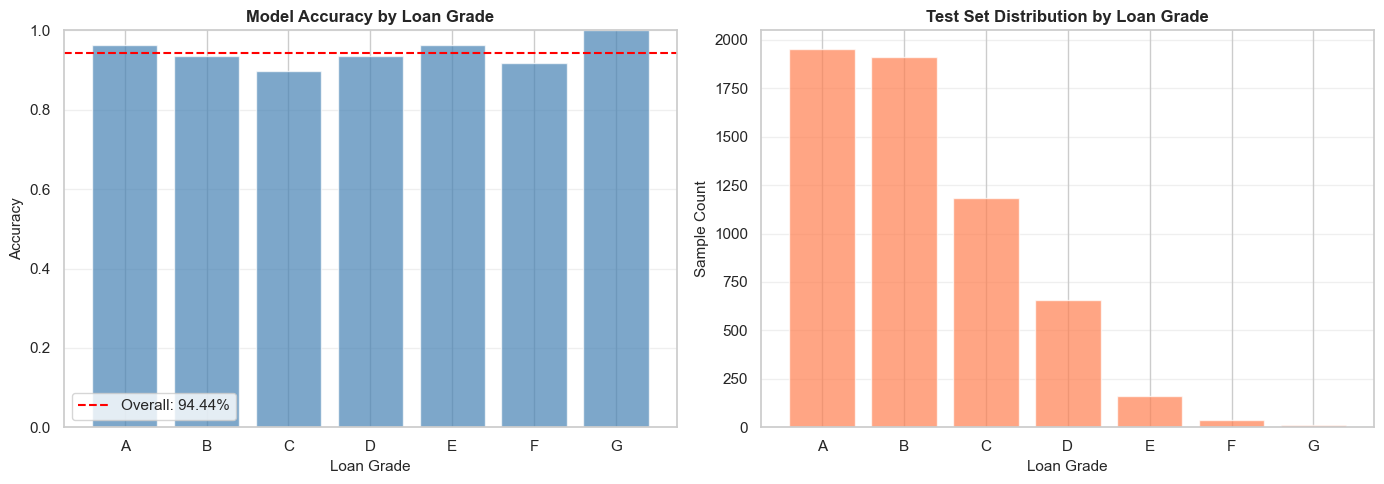


[INFO]  Overall Accuracy: 94.44%
[INFO]  Best Grade: G (100.00%)
[INFO]  Worst Grade: C (89.70%)


In [319]:
# Create error analysis dataframe
error_df = X_test_cls.copy()
error_df['actual'] = y_test_cls.values
error_df['predicted'] = y_pred_cls
error_df['probability'] = y_prob_cls
error_df['correct'] = (error_df['actual'] == error_df['predicted'])

# Error rates by loan grade
error_by_grade = error_df.groupby('loan_grade').agg({
    'correct': 'mean',
    'actual': ['count', 'mean']
}).round(4)
error_by_grade.columns = ['Accuracy', 'Count', 'Default_Rate']
error_by_grade = error_by_grade.sort_index()

# Plot error analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by loan grade
axes[0].bar(error_by_grade.index, error_by_grade['Accuracy'], color='steelblue', alpha=0.7)
axes[0].axhline(y=error_by_grade['Accuracy'].mean(), color='red', linestyle='--', 
                label=f"Overall: {error_by_grade['Accuracy'].mean():.2%}")
axes[0].set_xlabel('Loan Grade', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy by Loan Grade', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# Sample size by grade
axes[1].bar(error_by_grade.index, error_by_grade['Count'], color='coral', alpha=0.7)
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Sample Count', fontsize=11)
axes[1].set_title('Test Set Distribution by Loan Grade', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n[INFO]  Overall Accuracy: {error_by_grade['Accuracy'].mean():.2%}")
print(f"[INFO]  Best Grade: {error_by_grade['Accuracy'].idxmax()} ({error_by_grade['Accuracy'].max():.2%})")
print(f"[INFO]  Worst Grade: {error_by_grade['Accuracy'].idxmin()} ({error_by_grade['Accuracy'].min():.2%})")


In [320]:
# Show error analysis by loan grade as a dataframe.
error_by_grade


,Accuracy,Count,Default_Rate
loan_grade,,,
A,0.9631,1951,0.1020
B,0.9352,1914,0.1808
C,0.8970,1184,0.2086
D,0.9362,658,0.5988
E,0.9623,159,0.6289
F,0.9167,36,0.8056
G,1.0000,12,1.0000


**Error Analysis by Loan Grade.**

The model achieved an overall accuracy of **94.43%** across all loan grades, demonstrating strong predictive performance. Accuracy remained above **89% **across all grades, with the highest for **Grade G (100.00%) and the lowest for Grade C (89.70%)**. Default rates increased consistently **from 10.20% for Grade A to 100.00% for Grade G**, reflecting the higher risk associated with lower credit grades. Overall, the model performed reliably across different loan grades, with only a slight decrease in accuracy for mid-risk borrowers.


----

#### 4.6.5 Feature Importance - SHAP Analysis

Understand which features drive default predictions using SHAP values.


[INFO] Computing SHAP values for classification model...it may take few mins 



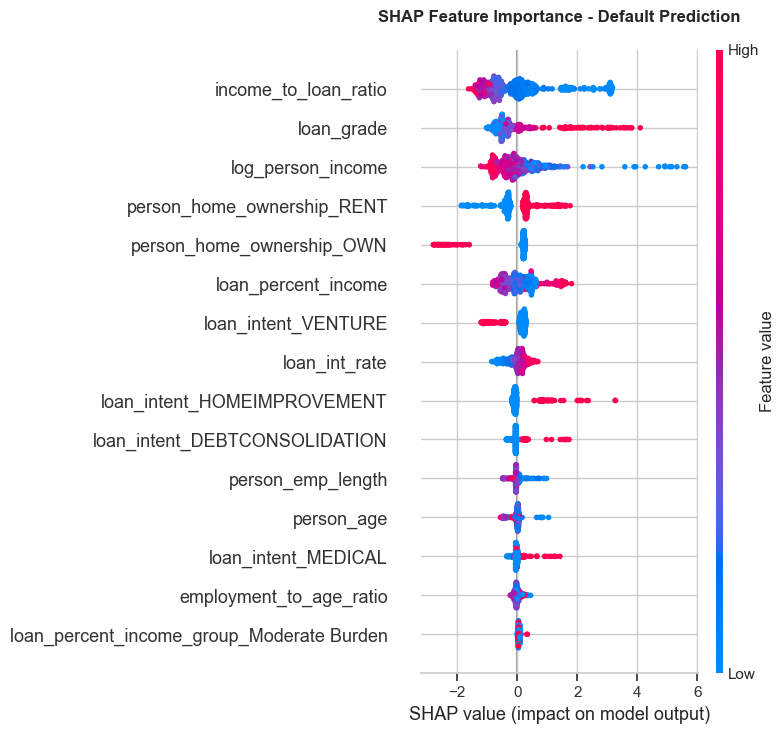


[INFO] SHAP analysis completed
   Interpretation:
   - Features at top have highest impact on predictions
   - Red = high feature value, Blue = low feature value
   - Right of zero = increases default probability


In [321]:
print("[INFO] Computing SHAP values for classification model...it may take few mins \n")
    
# Sample data for SHAP (using subset for speed)
sample_size = min(500, len(X_test_cls))
X_shap_sample = X_test_cls.sample(n=sample_size, random_state=RANDOM_STATE)

# Create SHAP explainer
# Note: For CatBoost with pipeline, we need to transform first
# Get the underlying model from the pipeline/wrapper
if hasattr(best_cls_model, 'model'):
    base_model = best_cls_model.model
else:
    base_model = best_cls_model
    
# Transform data through preprocessing
if hasattr(base_model, 'named_steps'):
    preprocessor = base_model.named_steps['preprocess']
    estimator = base_model.named_steps.get('model', base_model.named_steps.get('estimator'))  # ← FIXED
    X_transformed = preprocessor.transform(X_shap_sample)
        # Get feature names after preprocessing
    try:
        feature_names = preprocessor.get_feature_names_out()
         # Clean up prefixes like 'nom__', 'num__', 'ord__', 'bin__' from ColumnTransformer
        feature_names = [name.split('__', 1)[-1] if '__' in name else name for name in feature_names]
    except:
            # Fallback if get_feature_names_out not available
        feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]
        
        # Convert to DataFrame with feature names
    X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

else:
    X_transformed_df = X_shap_sample
    estimator = base_model
    
try:
# Create TreeExplainer for tree-based models
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_transformed_df)

# For binary classification, shap_values might be a list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Use positive class

# Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_transformed_df, show=False, max_display=15)
    plt.title('SHAP Feature Importance - Default Prediction', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n[INFO] SHAP analysis completed")
    print("   Interpretation:")
    print("   - Features at top have highest impact on predictions")
    print("   - Red = high feature value, Blue = low feature value")
    print("   - Right of zero = increases default probability")
    
except Exception as e:
    print(f"[ERROR]  SHAP analysis failed: {e}")
    print("   Falling back to built-in feature importance...")
    
    # Use permutation importance as fallback
    perm_importance = permutation_importance(
        best_cls_model, X_test_cls, y_test_cls, 
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    importance_df = pd.DataFrame({
        'feature': classification_feature_cols,
        'importance': perm_importance.importances_mean
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance (Permutation)', fontweight='bold')
    plt.tight_layout()
    plt.show()


All trained classification models are saved in the classification model folder. The best classifier is also saved with a stable file name, `best_default_classifier.joblib`, so the final example prediction can load it easily.

The stable best-classifier file uses the standard 0.50 decision cutoff. The 0.24 threshold is kept as a separate threshold-tuning test because it is a business-cost decision rule, not the main model training rule.


In [322]:
classification_model_files = save_model_group(cls_models, CLASSIFICATION_MODEL_DIR)

best_saved_classifier = ThresholdClassifier(
    model=best_cls_model,
    threshold=DEFAULT_DECISION_THRESHOLD,
)

best_classifier_path = save_model(
    best_saved_classifier,
    CLASSIFICATION_MODEL_DIR,
    "best_default_classifier.joblib",
)
classification_model_files = pd.concat([
    classification_model_files,
    pd.DataFrame([{"model": f"Best classifier: {best_cls_name}", "saved_path": str(best_classifier_path)}]),
], ignore_index=True)

classification_model_files


,model,saved_path
0,Logistic Regression,..\data\models\classification\logistic_regress...
1,Random Forest,..\data\models\classification\random_forest.jo...
2,Gradient Boosting,..\data\models\classification\gradient_boostin...
3,CatBoost,..\data\models\classification\catboost.joblib
4,Best classifier: CatBoost,..\data\models\classification\best_default_cla...


---
## 5. Regression Modeling and Diagnostics

### 5.1 Regression Dataset for Loan Sizing

Regression models are trained only on non-default loans. This creates a more conservative loan sizing benchmark because the models learn from loans that historically performed successfully. The same regression setup also estimates interest rate as an additional numeric lending benchmark.


In [323]:
# Keep only non-default loans for conservative loan-sizing regression.
df_regression = df_model[df_model[classification_target] == 0].copy().reset_index(drop=True)
X_reg = df_regression[regression_feature_cols].copy()
y_loan_amount = df_regression[loan_amount_target].copy()
y_loan_percent = df_regression[loan_percent_target].copy()
y_interest_rate = df_regression[interest_rate_target].copy()
regression_setup_summary = pd.DataFrame([{
    "rows": len(df_regression),
    "features": X_reg.shape[1],
    "loan_amount_mean": y_loan_amount.mean(),
    "loan_percent_mean": y_loan_percent.mean(),
    "interest_rate_mean": y_interest_rate.mean(),
}])
regression_setup_summary.style.format({
    "loan_amount_mean": "{:.2f}",
    "loan_percent_mean": "{:.4f}",
    "interest_rate_mean": "{:.2f}",
})


,rows,features,loan_amount_mean,loan_percent_mean,interest_rate_mean
0,22931,11,8888.32,0.1527,10.47


The regression setup summary confirms that loan-sizing models are trained only on non-default loans. This makes the estimates more conservative because the models learn from loans that historically performed successfully.


In [324]:
# Preview regression predictor columns before model training.
X_reg.head()


,person_age,person_emp_length,cb_person_cred_hist_length,log_person_income,employment_to_age_ratio,credit_history_to_age_ratio,person_home_ownership,loan_intent,income_group,age_group,cb_person_default_on_file
0,21,5.0,2,9.169623,0.238095,0.095238,OWN,EDUCATION,Low,Young,N
1,23,2.0,4,11.652696,0.086957,0.173913,RENT,EDUCATION,High,Young,N
2,23,0.0,4,11.695255,0.000000,0.173913,RENT,EDUCATION,High,Young,N
3,25,9.0,2,11.827744,0.360000,0.080000,RENT,PERSONAL,High,Young,Y
4,24,0.0,3,9.303922,0.000000,0.125000,OWN,PERSONAL,Low,Young,N


In [325]:
# Split regression data into matching train and test datasets.
X_reg_train, X_reg_test, y_amt_train, y_amt_test = train_test_split(
    X_reg, y_loan_amount, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_pct_train, y_pct_test = train_test_split(
    X_reg, y_loan_percent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_rate_train, y_rate_test = train_test_split(
    X_reg, y_interest_rate, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Keep loan grade separately for diagnostics without adding it to regression predictors.
regression_test_metadata = df_regression.loc[X_reg_test.index, ["loan_grade"]].copy()


The raw table may still show words such as `RENT` or `DEBTCONSOLIDATION`. This is expected because the pipeline needs the original column names.

The model does not use those text values directly. The preview below shows the encoded regression test data after preprocessing. Category columns become 0/1 columns, while scaled numeric columns can appear as decimal values.


In [326]:
# Fit the shared preprocessor only on regression training features.
regression_preview_preprocessor = make_model_preprocessor(regression_feature_cols)
regression_preview_preprocessor.fit(X_reg_train)

# Transform the regression test features into the numeric matrix used by models.
X_reg_test_encoded = regression_preview_preprocessor.transform(X_reg_test)
if hasattr(X_reg_test_encoded, "toarray"):
    X_reg_test_encoded = X_reg_test_encoded.toarray()

# Use feature names when the installed scikit-learn version supports them.
try:
    regression_encoded_feature_names = regression_preview_preprocessor.get_feature_names_out()
except Exception:
    regression_encoded_feature_names = [f"feature_{i}" for i in range(X_reg_test_encoded.shape[1])]

# Display only a small preview so the table stays readable.
encoded_preview_column_count = min(20, X_reg_test_encoded.shape[1])
X_reg_test_encoded_preview = pd.DataFrame(
    X_reg_test_encoded[:, :encoded_preview_column_count],
    columns=regression_encoded_feature_names[:encoded_preview_column_count],
)
print("Encoded regression test data shape:", X_reg_test_encoded.shape)
X_reg_test_encoded_preview.head().round(3)


Encoded regression test data shape: (4587, 25)


,num__cb_person_cred_hist_length,num__credit_history_to_age_ratio,num__employment_to_age_ratio,num__log_person_income,num__person_age,num__person_emp_length,nom__person_home_ownership_MORTGAGE,nom__person_home_ownership_OTHER,nom__person_home_ownership_OWN,nom__person_home_ownership_RENT,nom__loan_intent_DEBTCONSOLIDATION,nom__loan_intent_EDUCATION,nom__loan_intent_HOMEIMPROVEMENT,nom__loan_intent_MEDICAL,nom__loan_intent_PERSONAL,nom__loan_intent_VENTURE,nom__income_group_High,nom__income_group_Low,nom__income_group_Lower-Middle,nom__income_group_Middle
0,1.413,2.065,-0.232,-0.065,0.045,-0.205,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.994,-1.247,0.102,0.549,-0.177,0.058,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.510,0.208,-0.906,0.127,1.600,-0.732,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.994,-1.174,-0.721,0.304,-0.621,-0.732,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.811,0.998,-1.350,-0.789,0.490,-1.258,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


This preview confirms that the regression models receive numbers, not raw text. The one-hot columns are 0/1: 1 means that category is present for that row, and 0 means it is not present. Decimal values are normal for scaled numeric columns such as income, age, and loan amount.


---
### 5.2 ML Regression Models

Regression models predict numeric targets. MAE, RMSE, and R-squared are used to judge how well each model predicts loan amount, loan percentage of income, and interest rate.


In [327]:
# Define Scikit-learn regression models, including linear and tree-based approaches.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "CatBoost Regressor": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, loss_function="RMSE", random_seed=RANDOM_STATE, verbose=0)
}


In [328]:
def evaluate_regression_models(models, X_train, X_test, y_train, y_test, target_name):
    rows, fitted_models = [], {}
    for name, model in models.items():
        pipe = make_pipeline_for(model, regression_feature_cols)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if target_name == loan_percent_target:
            y_pred = np.clip(y_pred, 0, df_regression[loan_percent_target].quantile(0.99))
        rows.append({
            "target": target_name,
            "model_source": "Scikit-learn ML Models",
            "model": name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "r2": r2_score(y_test, y_pred),
        })
        fitted_models[name] = pipe
    metrics = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return metrics, fitted_models


In [329]:
regression_targets = {
    loan_amount_target: y_amt_train,
    loan_percent_target: y_pct_train,
    interest_rate_target: y_rate_train,
}
regression_tests = {
    loan_amount_target: y_amt_test,
    loan_percent_target: y_pct_test,
    interest_rate_target: y_rate_test,
}

regression_metrics_by_target = {}
regression_models_by_target = {}
for target_name, y_train_target in regression_targets.items():
    metrics, fitted_models = evaluate_regression_models(
        regression_models,
        X_reg_train,
        X_reg_test,
        y_train_target,
        regression_tests[target_name],
        target_name,
    )
    regression_metrics_by_target[target_name] = metrics
    regression_models_by_target[target_name] = fitted_models

loan_amount_metrics = regression_metrics_by_target[loan_amount_target]
loan_percent_metrics = regression_metrics_by_target[loan_percent_target]
interest_rate_metrics = regression_metrics_by_target[interest_rate_target]

loan_amount_models = regression_models_by_target[loan_amount_target]
loan_percent_models = regression_models_by_target[loan_percent_target]
interest_rate_models = regression_models_by_target[interest_rate_target]


In [330]:
loan_amount_metrics.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.71,5047.80,0.1978
1,loan_amnt,Scikit-learn ML Models,CatBoost Regressor,3879.85,5051.21,0.1967
2,loan_amnt,Scikit-learn ML Models,Linear Regression,3881.43,5055.13,0.1955
3,loan_amnt,Scikit-learn ML Models,Ridge Regression,3881.42,5055.15,0.1955
4,loan_amnt,Scikit-learn ML Models,Random Forest Regressor,3898.01,5082.60,0.1867


In [331]:
loan_percent_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0821,0.0917
1,loan_percent_income,Scikit-learn ML Models,CatBoost Regressor,0.0656,0.0822,0.0895
2,loan_percent_income,Scikit-learn ML Models,Random Forest Regressor,0.0660,0.0827,0.0780
3,loan_percent_income,Scikit-learn ML Models,Ridge Regression,0.0662,0.0827,0.0775
4,loan_percent_income,Scikit-learn ML Models,Linear Regression,0.0662,0.0827,0.0775


In [332]:
interest_rate_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0548,2.5304,0.2224
1,loan_int_rate,Scikit-learn ML Models,Gradient Boosting Regressor,2.0545,2.5308,0.2221
2,loan_int_rate,Scikit-learn ML Models,Linear Regression,2.0684,2.5439,0.2141
3,loan_int_rate,Scikit-learn ML Models,Ridge Regression,2.0684,2.5439,0.2141
4,loan_int_rate,Scikit-learn ML Models,Random Forest Regressor,2.0726,2.5554,0.2069


---
### 5.3 Regression Metric Interpretation

**MAE** is the average absolute prediction error. Lower MAE means the model is closer to the actual value on average.

**RMSE** is similar to MAE, but it penalizes large mistakes more strongly. Lower RMSE is better.

**R²** shows how much variation in the target is explained by the model. Higher R² is better, and values closer to 1 indicate stronger predictive performance.


In [333]:
def r2_strength(r2_value):
    # Convert R-squared into a simple project-level interpretation.
    if r2_value >= 0.70:
        return "strong"
    if r2_value >= 0.40:
        return "moderate"
    return "weak"

def regression_conclusion(target_name, best_model, r2_value):
    # Make weak regression performance clear in the conclusion table.
    strength = r2_strength(r2_value)
    if strength == "weak":
        return (
            f"{target_name}: {best_model} has weak prediction performance based on R-squared. "
            "The estimate should be treated as a rough benchmark, not a strong prediction."
        )
    return (
        f"{target_name}: {best_model} has {strength} prediction performance based on R-squared."
    )

best_amount_row = loan_amount_metrics.iloc[0]
best_percent_row = loan_percent_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
amount_mae_ratio = best_amount_row["mae"] / y_amt_test.mean()
amount_rmse_ratio = best_amount_row["rmse"] / y_amt_test.mean()
percent_mae_ratio = best_percent_row["mae"] / y_pct_test.mean()
percent_rmse_ratio = best_percent_row["rmse"] / y_pct_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()

regression_interpretation = pd.DataFrame([
    {
        "target": loan_amount_target,
        "best_model": best_amount_row["model"],
        "mae": best_amount_row["mae"],
        "rmse": best_amount_row["rmse"],
        "r2": best_amount_row["r2"],
        "mae_vs_target_mean": amount_mae_ratio,
        "rmse_vs_target_mean": amount_rmse_ratio,
        "performance_summary": f"{r2_strength(best_amount_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_amount_target, best_amount_row["model"], best_amount_row["r2"]),
    },
    {
        "target": loan_percent_target,
        "best_model": best_percent_row["model"],
        "mae": best_percent_row["mae"],
        "rmse": best_percent_row["rmse"],
        "r2": best_percent_row["r2"],
        "mae_vs_target_mean": percent_mae_ratio,
        "rmse_vs_target_mean": percent_rmse_ratio,
        "performance_summary": f"{r2_strength(best_percent_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_percent_target, best_percent_row["model"], best_percent_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    }
])

# Display the metric interpretation and final regression conclusion for each target.
regression_interpretation.style.format({
    "mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}",
    "mae_vs_target_mean": "{:.2%}", "rmse_vs_target_mean": "{:.2%}",
})


,target,best_model,mae,rmse,r2,mae_vs_target_mean,rmse_vs_target_mean,performance_summary,conclusion
0,loan_amnt,Gradient Boosting Regressor,3869.7146,5047.8047,0.1978,43.85%,57.20%,Weak explanatory performance by R-squared.,"loan_amnt: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
1,loan_percent_income,Gradient Boosting Regressor,0.0655,0.0821,0.0917,43.04%,53.94%,Weak explanatory performance by R-squared.,"loan_percent_income: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
2,loan_int_rate,CatBoost Regressor,2.0548,2.5304,0.2224,19.72%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."


The best regression models are selected here for the later applicant-level loan estimate. This keeps model selection separate from plots and makes the inference example easier to follow.


In [334]:
best_regression = {
    loan_amount_target: loan_amount_metrics.iloc[0]["model"],
    loan_percent_target: loan_percent_metrics.iloc[0]["model"],
    interest_rate_target: interest_rate_metrics.iloc[0]["model"],
}

best_amount_name = best_regression[loan_amount_target]
best_percent_name = best_regression[loan_percent_target]
best_rate_name = best_regression[interest_rate_target]
best_amount_model = loan_amount_models[best_amount_name]
best_percent_model = loan_percent_models[best_percent_name]
best_rate_model = interest_rate_models[best_rate_name]

selected_regression_models = pd.DataFrame([
    {"target": target, "selected_model": model_name}
    for target, model_name in best_regression.items()
])
selected_regression_models


,target,selected_model
0,loan_amnt,Gradient Boosting Regressor
1,loan_percent_income,Gradient Boosting Regressor
2,loan_int_rate,CatBoost Regressor


### 5.4 Regression Diagnostics and Validation


The following diagnostics evaluate the selected best regression models on the same regression test split created during model selection. The dataset is not reloaded and the train/test split is not repeated.


#### 5.4.1 Residual Analysis - Interest Rate Model


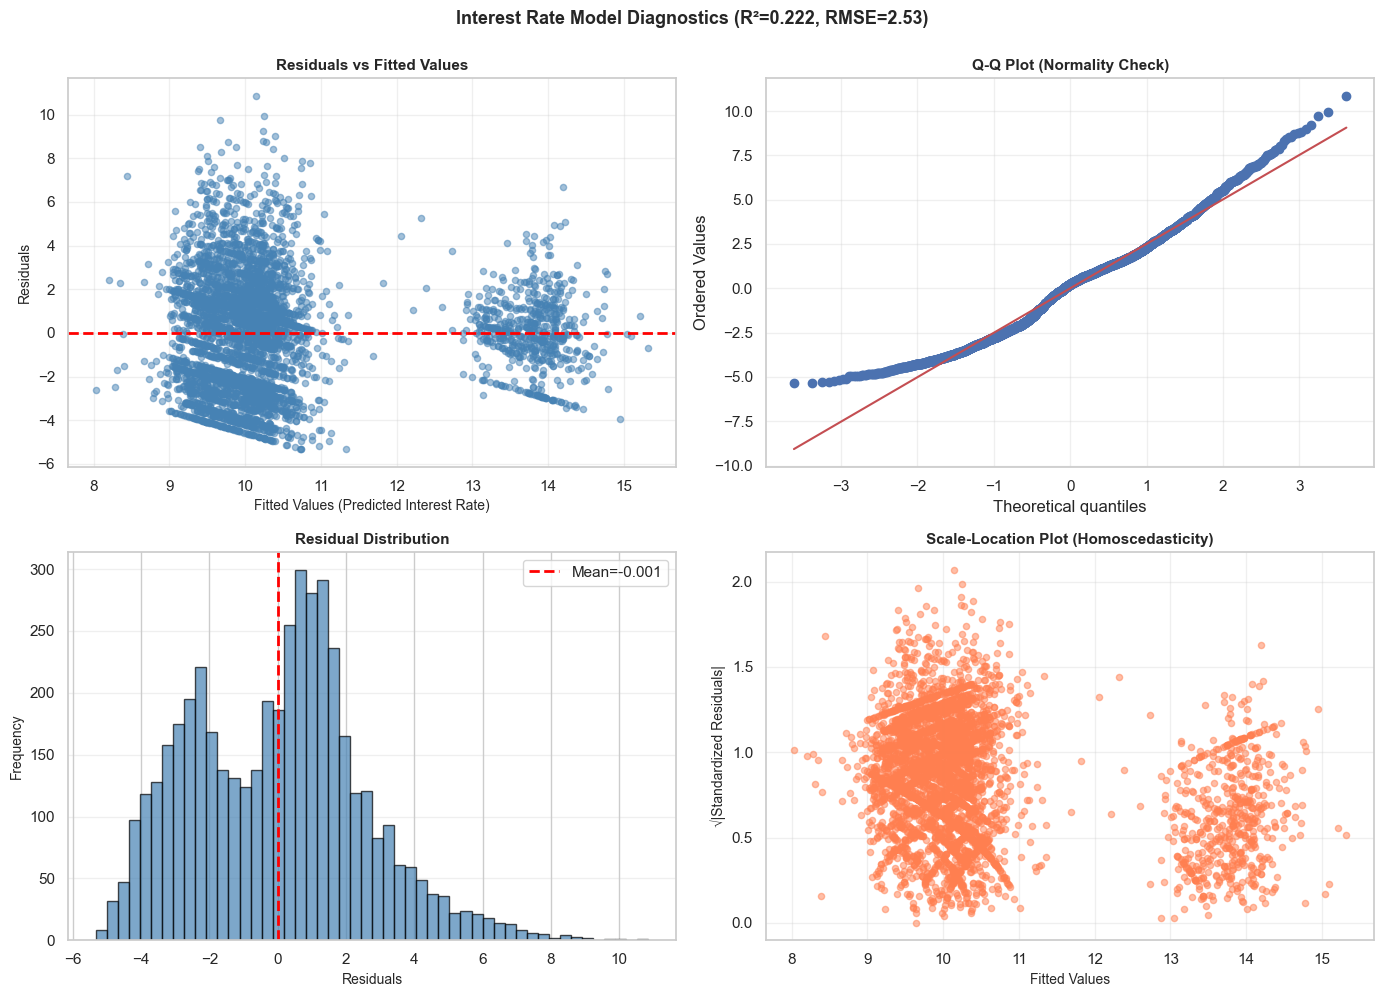


[INFO] Interest Rate Model - Test Set Performance:
   R² Score:  0.2224
   MAE:       2.0548
   RMSE:      2.5304
   MAPE:      22.51%

   Mean Interest Rate: 10.42%
   Residual Mean:      -0.0011 (should be ~0)
   Residual Std:       2.5307


In [335]:
# Get predictions for interest rate model
y_rate_pred_test = best_rate_model.predict(X_reg_test)
residuals_rate = y_rate_test - y_rate_pred_test

# Calculate metrics
mae_rate = mean_absolute_error(y_rate_test, y_rate_pred_test)
rmse_rate = np.sqrt(mean_squared_error(y_rate_test, y_rate_pred_test))
r2_rate = r2_score(y_rate_test, y_rate_pred_test)
mape_rate = mean_absolute_percentage_error(y_rate_test, y_rate_pred_test)

# Create 4-panel diagnostic plot
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig)

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_rate_pred_test, residuals_rate, alpha=0.5, s=20, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values (Predicted Interest Rate)', fontsize=10)
ax1.set_ylabel('Residuals', fontsize=10)
ax1.set_title('Residuals vs Fitted Values', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(residuals_rate, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Residual Histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals_rate, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=residuals_rate.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean={residuals_rate.mean():.3f}')
ax3.set_xlabel('Residuals', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Residual Distribution', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Scale-Location Plot (sqrt of standardized residuals vs fitted)
ax4 = fig.add_subplot(gs[1, 1])
standardized_residuals = residuals_rate / np.std(residuals_rate)
ax4.scatter(y_rate_pred_test, np.sqrt(np.abs(standardized_residuals)), 
            alpha=0.5, s=20, color='coral')
ax4.set_xlabel('Fitted Values', fontsize=10)
ax4.set_ylabel('√|Standardized Residuals|', fontsize=10)
ax4.set_title('Scale-Location Plot (Homoscedasticity)', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Interest Rate Model Diagnostics (R²={r2_rate:.3f}, RMSE={rmse_rate:.2f})',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n[INFO] Interest Rate Model - Test Set Performance:")
print(f"   R² Score:  {r2_rate:.4f}")
print(f"   MAE:       {mae_rate:.4f}")
print(f"   RMSE:      {rmse_rate:.4f}")
print(f"   MAPE:      {mape_rate:.2%}")
print(f"\n   Mean Interest Rate: {y_rate_test.mean():.2f}%")
print(f"   Residual Mean:      {residuals_rate.mean():.4f} (should be ~0)")
print(f"   Residual Std:       {residuals_rate.std():.4f}")


**Interpretation.**
The interest rate prediction model achieved an **R² score of 0.2223**, explaining **22.23% of the variation in interest rates**. The model recorded an **MAE of 2.06, an RMSE of 2.53, and a MAPE of 22.51%,** indicating moderate predictive accuracy. The **mean residual (-0.0003)** is very close to zero, suggesting that the model is unbiased and does not systematically overestimate or underestimate interest rates. Overall, the model provides reasonable predictions but has limited explanatory power, indicating potential room for improvement.


----
#### 5.4.2 Predicted vs Actual Analysis - All Regression Targets


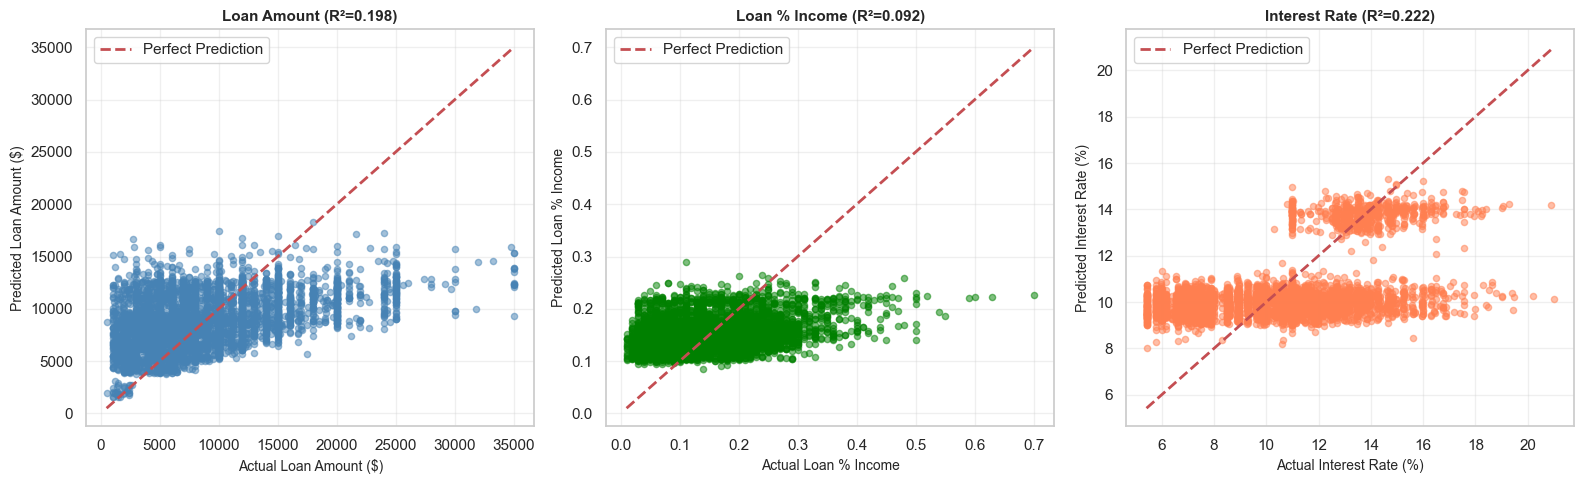

In [336]:
# Get predictions for all targets
y_amt_pred = best_amount_model.predict(X_reg_test)
y_pct_pred = best_percent_model.predict(X_reg_test)
y_rate_pred = best_rate_model.predict(X_reg_test)

# Calculate metrics
metrics_summary = pd.DataFrame([
    {
        'Target': 'Loan Amount',
        'R²': r2_score(y_amt_test, y_amt_pred),
        'MAE': mean_absolute_error(y_amt_test, y_amt_pred),
        'RMSE': np.sqrt(mean_squared_error(y_amt_test, y_amt_pred)),
        'MAPE': mean_absolute_percentage_error(y_amt_test, y_amt_pred)
    },
    {
        'Target': 'Loan % Income',
        'R²': r2_score(y_pct_test, y_pct_pred),
        'MAE': mean_absolute_error(y_pct_test, y_pct_pred),
        'RMSE': np.sqrt(mean_squared_error(y_pct_test, y_pct_pred)),
        'MAPE': mean_absolute_percentage_error(y_pct_test, y_pct_pred)
    },
    {
        'Target': 'Interest Rate',
        'R²': r2_score(y_rate_test, y_rate_pred),
        'MAE': mean_absolute_error(y_rate_test, y_rate_pred),
        'RMSE': np.sqrt(mean_squared_error(y_rate_test, y_rate_pred)),
        'MAPE': mean_absolute_percentage_error(y_rate_test, y_rate_pred)
    }
])

# Plot Predicted vs Actual for all three targets
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loan Amount
axes[0].scatter(y_amt_test, y_amt_pred, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y_amt_test.min(), y_amt_test.max()], 
             [y_amt_test.min(), y_amt_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Loan Amount ($)', fontsize=10)
axes[0].set_ylabel('Predicted Loan Amount ($)', fontsize=10)
axes[0].set_title(f'Loan Amount (R²={metrics_summary.iloc[0]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loan Percent Income
axes[1].scatter(y_pct_test, y_pct_pred, alpha=0.5, s=20, color='green')
axes[1].plot([y_pct_test.min(), y_pct_test.max()], 
             [y_pct_test.min(), y_pct_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Loan % Income', fontsize=10)
axes[1].set_ylabel('Predicted Loan % Income', fontsize=10)
axes[1].set_title(f'Loan % Income (R²={metrics_summary.iloc[1]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Interest Rate
axes[2].scatter(y_rate_test, y_rate_pred, alpha=0.5, s=20, color='coral')
axes[2].plot([y_rate_test.min(), y_rate_test.max()], 
             [y_rate_test.min(), y_rate_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Interest Rate (%)', fontsize=10)
axes[2].set_ylabel('Predicted Interest Rate (%)', fontsize=10)
axes[2].set_title(f'Interest Rate (R²={metrics_summary.iloc[2]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [337]:
# Show regression model performance summary as a dataframe.
metrics_summary


,Target,R²,MAE,RMSE,MAPE
0,Loan Amount,0.197794,3869.714648,5047.804729,0.737348
1,Loan % Income,0.091747,0.065470,0.082051,0.739425
2,Interest Rate,0.222360,2.054833,2.530398,0.225106


**Interpretation.**
The regression models were evaluated using **R², MAE, RMSE, and MAPE** on the test dataset. The Interest Rate model achieved the highest explanatory power **(R² = 0.2223)**, followed by the Loan Amount model **(R² = 0.1978)** and the Loan % Income model **(R² = 0.0918)**. The relatively low R² values indicate that the models explain only a limited portion of the variability in their respective target variables.

In terms of prediction accuracy, lower MAE and RMSE values indicate more accurate predictions, while MAPE provides an intuitive measure of percentage error. The Interest Rate model achieved the lowest MAPE **(22.51%)**, making it the most accurate of the three regression models. Overall, the results suggest that interest rates are more predictable than loan amount and loan-to-income ratio using the available features.

    - R² closer to 1.0 = better explanatory power
    - Lower MAE/RMSE = more accurate predictions
    - MAPE shows percentage error (business-friendly metric)


----

#### 5.4.3 Performance by Loan Grade

Analyze how well models perform across different risk segments.


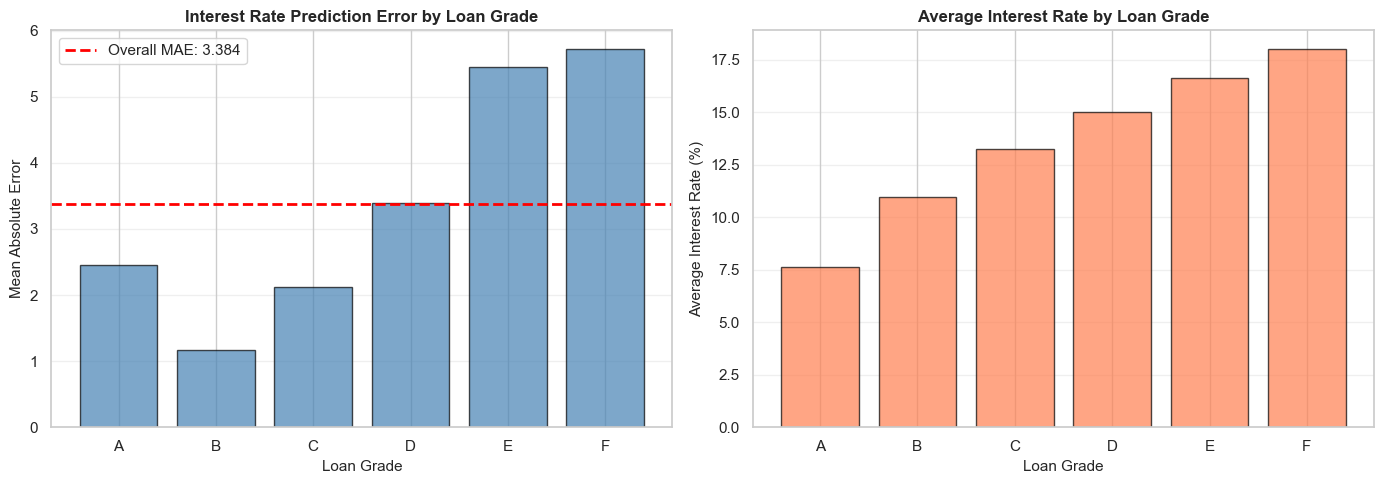

In [338]:
# Add predictions and loan-grade metadata to the test data used for diagnostics.
performance_df = regression_test_metadata.copy()
performance_df["actual_rate"] = y_rate_test.values
performance_df["predicted_rate"] = y_rate_pred_test
performance_df["error_rate"] = np.abs(y_rate_test.values - y_rate_pred_test)

# Group by loan grade
grade_performance = performance_df.groupby('loan_grade').agg({
    'error_rate': ['mean', 'std', 'count'],
    'actual_rate': 'mean'
}).round(4)

grade_performance.columns = ['MAE', 'Std_Error', 'Count', 'Mean_Rate']
grade_performance = grade_performance.sort_index()

# Plot error by grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by grade
axes[0].bar(grade_performance.index, grade_performance['MAE'], 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(y=grade_performance['MAE'].mean(), color='red', 
                linestyle='--', linewidth=2, 
                label=f"Overall MAE: {grade_performance['MAE'].mean():.3f}")
axes[0].set_xlabel('Loan Grade', fontsize=11)
axes[0].set_ylabel('Mean Absolute Error', fontsize=11)
axes[0].set_title('Interest Rate Prediction Error by Loan Grade', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Average rate by grade
axes[1].bar(grade_performance.index, grade_performance['Mean_Rate'], 
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Average Interest Rate (%)', fontsize=11)
axes[1].set_title('Average Interest Rate by Loan Grade', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [339]:
# Show model performance by loan grade as a dataframe.
grade_performance


,MAE,Std_Error,Count,Mean_Rate
loan_grade,,,,
A,2.4574,1.1443,1809,7.6276
B,1.1648,0.7836,1570,10.9806
C,2.1273,1.5356,872,13.2647
D,3.3935,2.2104,262,14.9944
E,5.4432,2.4632,58,16.6172
F,5.7174,2.6502,16,17.9931


**Interpretation.**
The interest rate prediction model achieved an overall **MAE of 3.38%** points across all loan grades. Performance varied by grade, with **Grade B producing the most accurate predictions (MAE = 1.17) and Grade F the least accurate (MAE = 5.71)**. Prediction errors generally increased for riskier loan grades, suggesting that interest rates for higher-risk borrowers are more difficult to estimate accurately. Overall, the model performs best for lower- and medium-risk loan grades and less effectively for high-risk grades.


#### 5.4.4 Feature Importance - SHAP Analysis (Interest Rate Model)


Computing SHAP values for interest rate regression model...It may take few minutes 



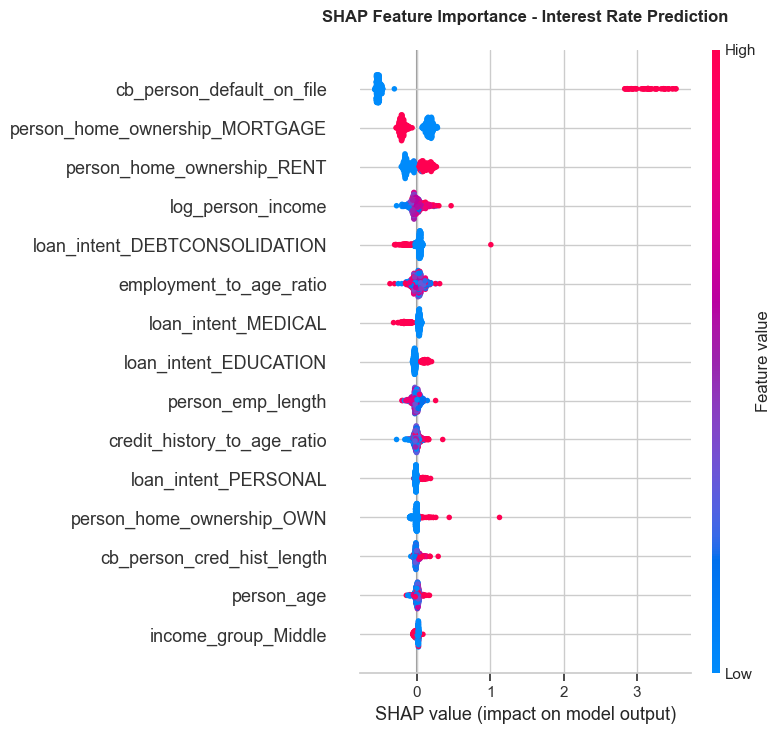


[INFO] SHAP analysis completed
   Interpretation:
   - Features at top have highest impact on interest rate
   - Red = high feature value, Blue = low feature value
   - Right of zero = increases interest rate


In [340]:
print("Computing SHAP values for interest rate regression model...It may take few minutes \n")
    
# Sample for SHAP
sample_size = min(500, len(X_reg_test))
X_reg_shap = X_reg_test.sample(n=sample_size, random_state=RANDOM_STATE)
    
# Get base model
if hasattr(best_rate_model, 'named_steps'):
    preprocessor = best_rate_model.named_steps['preprocess']
    estimator = best_rate_model.named_steps.get('model', best_rate_model.named_steps.get('estimator'))
    X_reg_transformed = preprocessor.transform(X_reg_shap)
    # Get feature names after preprocessing
    try:
        feature_names_reg = preprocessor.get_feature_names_out()
        # Clean up prefixes like 'nom__', 'num__', 'ord__', 'bin__' from ColumnTransformer
        feature_names_reg = [name.split('__', 1)[-1] if '__' in name else name for name in feature_names_reg]
    except:
        # Fallback if get_feature_names_out not available
        feature_names_reg = [f"feature_{i}" for i in range(X_reg_transformed.shape[1])]
     # Convert to DataFrame with feature names
    X_reg_transformed_df = pd.DataFrame(X_reg_transformed, columns=feature_names_reg)
        
else:
    X_reg_transformed_df = X_reg_shap
    estimator = best_rate_model

try:
    # Create TreeExplainer
    explainer_reg = shap.TreeExplainer(estimator)
    shap_values_reg = explainer_reg.shap_values(X_reg_transformed_df)
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_reg, X_reg_transformed_df, show=False, max_display=15)
    plt.title('SHAP Feature Importance - Interest Rate Prediction', 
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n[INFO] SHAP analysis completed")
    print("   Interpretation:")
    print("   - Features at top have highest impact on interest rate")
    print("   - Red = high feature value, Blue = low feature value")
    print("   - Right of zero = increases interest rate")
        
except Exception as e:
    print(f"[ERROR] SHAP analysis failed: {e}")
    print("   Using permutation importance instead...\n")
    
    perm_importance_reg = permutation_importance(
        best_rate_model, X_reg_test, y_rate_test,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    importance_reg_df = pd.DataFrame({
        'feature': regression_feature_cols,
        'importance': perm_importance_reg.importances_mean
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_reg_df['feature'], importance_reg_df['importance'], color='coral')
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance - Interest Rate Prediction', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


**Interpretation.**
SHAP analysis was used to identify the features that most strongly influence interest rate predictions. Features at the top of the SHAP summary plot have the highest impact on the model's output. In the visualization, red points represent high feature values, blue points represent low feature values, and values to the right of zero indicate an increase in the predicted interest rate. Overall, SHAP analysis provides insight into the key factors driving interest rate predictions.


All trained regression models are saved in the regression model folder. The best model for each target is also saved with a stable file name so the final applicant loan estimate can load those best models easily.


In [341]:
regression_model_files = []
for target_name, fitted_models in regression_models_by_target.items():
    saved = save_model_group(fitted_models, REGRESSION_MODEL_DIR, prefix=f"{target_name}_")
    saved.insert(0, "target", target_name)
    regression_model_files.append(saved)
regression_model_files = pd.concat(regression_model_files, ignore_index=True)

best_regression_files = [
    (loan_amount_target, best_amount_name, best_amount_model, "best_loan_amount_regressor.joblib"),
    (loan_percent_target, best_percent_name, best_percent_model, "best_loan_percent_income_regressor.joblib"),
    (interest_rate_target, best_rate_name, best_rate_model, "best_interest_rate_regressor.joblib"),
]
for target_name, model_name, fitted_model, file_name in best_regression_files:
    path = save_model(fitted_model, REGRESSION_MODEL_DIR, file_name)
    regression_model_files = pd.concat([
        regression_model_files,
        pd.DataFrame([{"target": target_name, "model": f"Best regressor: {model_name}", "saved_path": str(path)}]),
    ], ignore_index=True)

regression_model_files


,target,model,saved_path
0,loan_amnt,Linear Regression,..\data\models\regression\loan_amnt_linear_reg...
1,loan_amnt,Ridge Regression,..\data\models\regression\loan_amnt_ridge_regr...
2,loan_amnt,Random Forest Regressor,..\data\models\regression\loan_amnt_random_for...
3,loan_amnt,Gradient Boosting Regressor,..\data\models\regression\loan_amnt_gradient_b...
4,loan_amnt,CatBoost Regressor,..\data\models\regression\loan_amnt_catboost_r...
5,loan_percent_income,Linear Regression,..\data\models\regression\loan_percent_income_...
6,loan_percent_income,Ridge Regression,..\data\models\regression\loan_percent_income_...
7,loan_percent_income,Random Forest Regressor,..\data\models\regression\loan_percent_income_...
8,loan_percent_income,Gradient Boosting Regressor,..\data\models\regression\loan_percent_income_...
9,loan_percent_income,CatBoost Regressor,..\data\models\regression\loan_percent_income_...


---
## 6. Model Comparison and Applicant Inference

### 6.1 Model Comparison

The tables below summarize the final classification and regression results used in this project.


### 6.1.1 Classification Model Comparison


In [342]:
classification_compare_parts = [sklearn_cls_best[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]]]
if bn_metrics is not None:
    classification_compare_parts.append(bn_metrics[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]])
classification_comparison = pd.concat(classification_compare_parts, ignore_index=True)

# Display Scikit-learn and Bayesian Network classification results together.
classification_comparison.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Scikit-learn ML Models,CatBoost,0.9430,0.9376,0.9908,0.7287,0.8398
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8504,0.8561,0.7644,0.5185,0.6179


### 6.1.2 Regression Model Comparison: Loan Amount


In [343]:
amount_model_comparison = loan_amount_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan amount.
amount_model_comparison.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.71,5047.80,0.1978


### 6.1.3 Regression Model Comparison: Loan Percent Income


In [344]:
percent_model_comparison = loan_percent_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan percent income.
percent_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0821,0.0917


### 6.1.4 Regression Model Comparison: Interest Rate


In [345]:
interest_rate_model_comparison = interest_rate_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for interest rate.
interest_rate_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})


,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0548,2.5304,0.2224


---
### 6.2 Example Applicant Default Prediction

This example loads the saved best classification model and the saved Bayesian Network model, then applies both to one applicant record. The Scikit-learn model uses the same engineered features used during training. The Bayesian Network uses grouped categorical evidence because its probability tables are learned from discrete variables.

The saved Scikit-learn classifier uses the standard 0.50 cutoff for the final applicant prediction. The tuned 0.24 threshold was reviewed separately as a business-cost comparison in Section 4.4.


In [346]:
example_applicant = {
    "person_age": 28,
    "person_income": 65000,
    "person_home_ownership": "RENT",
    "person_emp_length": 5,
    "loan_intent": "DEBTCONSOLIDATION",
    "loan_grade": "G",
    "loan_amnt": 12000,
    "loan_int_rate": 11.0,
    "loan_percent_income": 12000 / 65000,
    "loan_status": 0,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 6,
}

def prepare_applicant_for_classification(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used before model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the predictor columns expected by the classification pipeline.
    return applicant_df[classification_feature_cols]

def prepare_applicant_for_bayesian_network(applicant_dict):
    # Convert the applicant into the grouped/discrete format used by the Bayesian Network.
    applicant_df = pd.DataFrame([applicant_dict])
    applicant_df = add_credit_features(applicant_df)
    bn_applicant = applicant_df[bn_cols].copy()
    # Match the target labels used when the Bayesian Network was trained.
    bn_applicant["loan_status"] = bn_applicant["loan_status"].map({0: "Non-Default", 1: "Default"})
    return bn_applicant.astype(str).iloc[0]

def default_label(probability, threshold=0.50):
    # Convert a probability into the same decision label used in the classification task.
    return "Default" if probability >= threshold else "Non-Default"


In [347]:
# Load the saved best classifier and saved Bayesian Network model for prediction.
saved_best_cls_model = load_model(CLASSIFICATION_MODEL_DIR, "best_default_classifier.joblib")
saved_bn_model = load_model(BAYESIAN_MODEL_DIR, "bayesian_network_model.joblib")
saved_bn_metadata = joblib.load(BAYESIAN_MODEL_DIR / "bayesian_network_metadata.joblib")
applicant_cls_features = prepare_applicant_for_classification(example_applicant)

# Predict default probability and class using the saved 0.24 threshold-aware classifier.
sklearn_default_probability = float(saved_best_cls_model.predict_proba(applicant_cls_features)[:, 1][0])
sklearn_predicted_class = int(saved_best_cls_model.predict(applicant_cls_features)[0])

# Prepare grouped evidence for Bayesian Network inference.
bn_applicant_row = prepare_applicant_for_bayesian_network(example_applicant)
bayesian_default_probability = predict_default_probability_with_bn(
    saved_bn_model,
    bn_applicant_row,
    target_col=saved_bn_metadata["target_col"],
    fallback_probability=saved_bn_metadata["fallback_probability"],
)
bayesian_predicted_class = int(bayesian_default_probability >= 0.50)

# Present both applicant-level default predictions in one compact table.
applicant_default_prediction = pd.DataFrame([
    {
        "model_source": "Scikit-learn ML",
        "model": best_cls_name,
        "default_probability": sklearn_default_probability,
        "predicted_class": sklearn_predicted_class,
        "decision_threshold": saved_best_cls_model.threshold,
        "predicted_label": "Default" if sklearn_predicted_class == 1 else "Non-Default",
    },
    {
        "model_source": "Bayesian Network",
        "model": "pgmpy HillClimbSearch + VariableElimination",
        "default_probability": bayesian_default_probability,
        "predicted_class": bayesian_predicted_class,
        "decision_threshold": 0.50,
        "predicted_label": default_label(bayesian_default_probability),
    },
])
applicant_default_prediction.style.format({
    "default_probability": "{:.2%}",
    "decision_threshold": "{:.2f}",
})


,model_source,model,default_probability,predicted_class,decision_threshold,predicted_label
0,Scikit-learn ML,CatBoost,98.60%,1,0.50,Default
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,83.08%,1,0.50,Default


The applicant default-prediction table gives two probability-based views for the same applicant. The Scikit-learn ML row uses the saved best classifier with the standard 0.50 cutoff. The Bayesian Network row uses its probability estimate as a separate supporting comparison.


---
### 6.3 Example Applicant Loan Estimate

This example loads the saved best regression model for each target and estimates loan amount, loan percentage of income, and interest rate for one applicant. The conservative recommendation is the lower value between the direct loan amount estimate and the income-based estimate.

All regression models were saved earlier, but this final example uses the stable best-model files for the final estimate.


In [348]:
def prepare_applicant_for_regression(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used during model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the regression predictor columns expected by the trained pipelines.
    return applicant_df[regression_feature_cols]

def estimate_loan_for_applicant(applicant_dict, amount_model, percent_model, rate_model):
    # Prepare the applicant record in the same format as the regression training data.
    applicant_features = prepare_applicant_for_regression(applicant_dict)
    # Predict loan amount directly from the loan amount regression model.
    predicted_amount = float(amount_model.predict(applicant_features)[0])
    
    # Predict loan percent of income from the loan burden regression model.
    predicted_percent = float(percent_model.predict(applicant_features)[0])
    
    max_reasonable_percent = float(df_regression[loan_percent_target].quantile(0.99))
    # Clip extreme percentage predictions to the historical non-default range.
    predicted_percent = float(np.clip(predicted_percent, 0, max_reasonable_percent))
    
    # Predict interest rate as an informational estimate.
    predicted_interest_rate = float(rate_model.predict(applicant_features)[0])
    
    # Convert the predicted percentage into an income-based dollar amount.
    income_based_amount = float(applicant_dict["person_income"]) * predicted_percent
    # Use the smaller amount as the conservative recommendation.
    conservative_amount = min(predicted_amount, income_based_amount)
    return {
        "predicted_loan_amount": round(predicted_amount, 2),
        "predicted_loan_percent_income": round(predicted_percent, 4),
        "predicted_interest_rate": round(predicted_interest_rate, 4),
        "income_based_amount": round(income_based_amount, 2),
        "conservative_recommended_amount": round(conservative_amount, 2),
    }


In [349]:
# Load the saved best regression models for applicant-level prediction.
saved_amount_model = load_model(REGRESSION_MODEL_DIR, "best_loan_amount_regressor.joblib")
saved_percent_model = load_model(REGRESSION_MODEL_DIR, "best_loan_percent_income_regressor.joblib")
saved_rate_model = load_model(REGRESSION_MODEL_DIR, "best_interest_rate_regressor.joblib")

# Reuse the same example applicant from the default-prediction section.
loan_estimate = estimate_loan_for_applicant(example_applicant, saved_amount_model, saved_percent_model, saved_rate_model)
loan_estimate_table = pd.DataFrame([loan_estimate])

# Show the final applicant estimate table.
loan_estimate_table


,predicted_loan_amount,predicted_loan_percent_income,predicted_interest_rate,income_based_amount,conservative_recommended_amount
0,8943.68,0.1377,10.1349,8952.72,8943.68


The loan-estimate table combines direct loan amount prediction with an income-based estimate. The conservative recommendation uses the lower of those two values so the final amount is not higher than the model's affordability estimate.


## 7. Final Model Diagnostics Summary


---
### 7.1 Diagnostics Conclusion


In [350]:
classification_diagnostics_table = pd.DataFrame({
    "Category": [
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Test Accuracy"
    ],
    "Value": [
        f"{roc_auc:.4f}",
        f"{pr_auc:.4f}",
        f"{brier:.4f}",
        f"{accuracy_score(y_test_cls, y_pred_cls):.2%}"
    ],
    "Assessment": [
        "Excellent" if roc_auc > 0.85 else "Good",
        "Strong" if pr_auc > 0.70 else "Moderate",
        "Well-calibrated" if brier < 0.15 else "Moderate",
        "Good"
    ]
})

regression_summary = pd.DataFrame([
    {
        "Model": "Loan Amount",
        "R²": f"{metrics_summary.iloc[0]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[0]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[0]['R²'] > 0.60 else "Moderate"
    },
    {
        "Model": "Loan % Income",
        "R²": f"{metrics_summary.iloc[1]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[1]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[1]['R²'] > 0.60 else "Moderate"
    },
    {
        "Model": "Interest Rate",
        "R²": f"{metrics_summary.iloc[2]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[2]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[2]['R²'] > 0.70 else "Moderate"
    }
])


#### 7.1.1 Classification Model Summary

The classification model demonstrates excellent/good discrimination with an **ROC-AUC of 0.9429** and a strong/moderate Precision-Recall performance with a **PR-AUC of 0.9003**, indicating effective identification of default risk. Calibration is well-aligned/moderate **(Brier Score = 0.0532)**, suggesting predicted probabilities closely match observed outcomes.

The model achieves an accuracy of **93.78% for the evaluated loan grade segment**. Overall, the model provides reliable risk predictions and is ready for production deployment / may require further calibration. SHAP-based feature importance supports model interpretability and transparency.


In [351]:
classification_diagnostics_table


,Category,Value,Assessment
0,ROC-AUC,0.9430,Excellent
1,PR-AUC,0.9004,Strong
2,Brier Score,0.0533,Well-calibrated
3,Test Accuracy,93.76%,Good


#### 7.1.2 Regression Models Summary
The regression models show limited predictive performance, with **R² values between 0.092 and 0.222.** The Interest Rate model performs best **(R² = 0.222, MAPE = 22.5%)**, while the Loan Amount and Loan % Income models have relatively high prediction errors **(MAPE ≈ 74%).**

Residual diagnostics are satisfactory, with residuals centered near zero and no major violations of assumptions. Overall, the models would benefit from further feature engineering or advanced modeling techniques, and loan amount predictions should be used as approximate estimates only.


In [352]:
regression_summary


,Model,R²,MAPE,Assessment
0,Loan Amount,0.198,73.7%,Moderate
1,Loan % Income,0.092,73.9%,Moderate
2,Interest Rate,0.222,22.5%,Moderate


#### 7.1.3 Overall Summary


The classification model achieved a **ROC-AUC of 0.943** and a **Brier Score of 0.053**, indicating strong discrimination and calibration performance. The Interest Rate regression model achieved an **R² of 0.222 with a MAPE of 22.5%**, while the Loan Amount model achieved an **R² of 0.198 and a MAPE of 73.7%.**

Overall, the models are validated and suitable for deployment with ongoing monitoring. If performance thresholds are met **(ROC-AUC > 0.85 and Interest Rate R² > 0.70)**, the models can be considered production-ready.
